<a href="https://colab.research.google.com/github/raphaelfarzankashani/first-ide-lab-js-intro-000/blob/master/Waves_MultiHead.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
from datasets import load_dataset
from transformers import AutoTokenizer

print("Loading tokenizer and dataset...")
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token # GPT-2 doesn't have a pad token by default

dataset = load_dataset("roneneldan/TinyStories", split="train", streaming=True)

Loading tokenizer and dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class AutoRegressiveWaveTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, num_frequencies=4, num_heads=8):
        super().__init__()
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.N = num_frequencies

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # Parameters for each head: [num_heads, head_dim, 3, N]
        self.W_q = nn.Parameter(torch.randn(num_heads, self.head_dim, 3, self.N) * 0.1)
        self.W_k = nn.Parameter(torch.randn(num_heads, self.head_dim, 3, self.N) * 0.1)

        self.W_v = nn.Linear(embed_dim, embed_dim)
        self.lm_head = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        B, S = x.shape
        h = self.embedding(x) # [B, S, embed_dim]

        # Split into heads: [B, S, H, D]
        h_split = h.view(B, S, self.num_heads, self.head_dim)

        # Calculate wave parameters: [B, S, H, D, N]
        # We ensure W_q/W_k are reshaped to match the h_split
        # W_q: [num_heads, head_dim, 3, N]
        q_params = torch.einsum('bshd, hdmn -> bshdmn', h_split, self.W_q)
        k_params = torch.einsum('bshd, hdmn -> bshdmn', h_split, self.W_k)

        # Slice parameters: [B, S, H, D, N]
        A_q, omega_q, phi_q = F.softplus(q_params[..., 0, :]), torch.abs(q_params[..., 1, :]) * 2.0, torch.tanh(q_params[..., 2, :]) * math.pi
        A_k, omega_k, phi_k = F.softplus(k_params[..., 0, :]), torch.abs(k_params[..., 1, :]) * 2.0, torch.tanh(k_params[..., 2, :]) * math.pi

        V = self.W_v(h).view(B, S, self.num_heads, self.head_dim)

        # Create positional time array: [1, S, 1, 1, 1]
        t = torch.arange(S, device=x.device).view(1, S, 1, 1, 1).float()

        # Synthesis: [B, S, H, D] (summing over N dimension)
        q_real = torch.sum(A_q * torch.cos(omega_q * t + phi_q), dim=-1)
        q_imag = torch.sum(A_q * torch.sin(omega_q * t + phi_q), dim=-1)
        k_real = torch.sum(A_k * torch.cos(omega_k * t + phi_k), dim=-1)
        k_imag = torch.sum(A_k * torch.sin(omega_k * t + phi_k), dim=-1)

        # Accumulate memory: [B, S, H, D, D]
        # Using ... ensures that we match the 4D input dimensions correctly
        kv_real = torch.cumsum(torch.einsum('bshd, bshe -> bshde', k_real, V), dim=1)
        kv_imag = torch.cumsum(torch.einsum('bshd, bshe -> bshde', k_imag, V), dim=1)

        # Context retrieval: [B, S, H, D]
        context_real = torch.einsum('bshd, bshde -> bshe', q_real, kv_real)
        context_imag = torch.einsum('bshd, bshde -> bshe', q_imag, kv_imag)

        # Normalization: [B, S, H, 1]
        # We need to sum keys over time to get the denominator
        k_real_sum = torch.cumsum(k_real, dim=1)
        k_imag_sum = torch.cumsum(k_imag, dim=1)

        # Normalizing the complex magnitudes
        denom = torch.clamp(torch.abs(
            torch.einsum('bshd, bshd -> bsh', q_real, k_real_sum) +
            torch.einsum('bshd, bshd -> bsh', q_imag, k_imag_sum)
        ), min=1e-5).unsqueeze(-1)

        # Final projection: [B, S, embed_dim]
        context_out = (context_real + context_imag) / denom
        return self.lm_head(h + context_out.view(B, S, self.embed_dim))

def get_batch(dataset, tokenizer, batch_size=32, seq_len=64):
    tokens = []
    for example in dataset:
        encoded = tokenizer.encode(example['text'] + tokenizer.eos_token)
        tokens.extend(encoded)
        while len(tokens) > (batch_size * seq_len) + 1:
            chunk = tokens[:(batch_size * seq_len) + 1]
            input_ids = torch.tensor(chunk[:-1]).view(batch_size, seq_len)
            targets = torch.tensor(chunk[1:]).view(batch_size, seq_len)
            yield input_ids, targets
            tokens = tokens[batch_size * seq_len:]

def get_batch(batch_size=32, seq_len=64):
    """
    Streams stories, encodes them, and chunks them into perfect [batch_size, seq_len] tensors.
    """
    tokens = []
    for example in dataset:
        # Encode the story and append the End-Of-Sentence (EOS) token!
        # This is what stops the "infinite hallucination" loop.
        encoded = tokenizer.encode(example['text'] + tokenizer.eos_token)
        tokens.extend(encoded)

        # When we have enough tokens for a full batch, yield it
        while len(tokens) > (batch_size * seq_len) + 1:
            # Grab exactly enough tokens for inputs and targets
            chunk = tokens[:(batch_size * seq_len) + 1]

            # Inputs: up to the second-to-last token
            input_ids = torch.tensor(chunk[:-1]).view(batch_size, seq_len)
            # Targets: shifted by one token into the future
            targets = torch.tensor(chunk[1:]).view(batch_size, seq_len)

            yield input_ids, targets

            # Remove the used tokens, keep the remainder for the next batch
            tokens = tokens[batch_size * seq_len:]

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Training on: {device}")

vocab_size = len(tokenizer) # 50257
model = AutoRegressiveWaveTransformer(vocab_size=vocab_size, embed_dim=64).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001) # Slightly lower LR for 64-dim
criterion = nn.CrossEntropyLoss()

print("Starting training...")
step = 0
max_steps = 5000 # Train for 5,000 steps to see real learning

# We pull infinitely from our streaming generator
for inputs, targets in get_batch(batch_size=32, seq_len=64):
    inputs, targets = inputs.to(device), targets.to(device)

    optimizer.zero_grad()
    logits = model(inputs)

    # Flatten the batch and sequence dimensions to calculate loss
    loss = criterion(logits.view(-1, vocab_size), targets.view(-1))

    loss.backward()
    optimizer.step()

    step += 1
    if step % 20 == 0:
        print(f"Step {step:04d} | Loss: {loss.item():.4f}")

    if step >= max_steps:
        break

print("Training complete!")

# ==========================================
# 4. TESTING THE MODEL
# ==========================================
def generate(model, prompt, max_new_tokens=20):
    model.eval()
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

    for _ in range(max_new_tokens):
        with torch.no_grad():
            logits = model(input_ids)
            # Get the predictions for the very last token in the sequence
            next_token_logits = logits[0, -1, :]

            # Greedy decoding (Temp = 0) to see pure logic
            next_token_id = torch.argmax(next_token_logits).unsqueeze(0).unsqueeze(0)

            input_ids = torch.cat([input_ids, next_token_id], dim=1)

            # Stop if the model predicts the EOS token
            if next_token_id.item() == tokenizer.eos_token_id:
                break

    return tokenizer.decode(input_ids[0])

print("\n--- Generation Test ---")
print(generate(model, "Once upon a time, there was a muddy river"))
print(generate(model, "The clever doctor said"))

Training on: cuda
Starting training...
Step 0020 | Loss: 11.2651
Step 0040 | Loss: 11.6521
Step 0060 | Loss: 9.9122
Step 0080 | Loss: 10.6324
Step 0100 | Loss: 8.6835
Step 0120 | Loss: 8.8325
Step 0140 | Loss: 9.3746
Step 0160 | Loss: 7.4465
Step 0180 | Loss: 7.2696
Step 0200 | Loss: 7.2500
Step 0220 | Loss: 6.7088


Token indices sequence length is longer than the specified maximum sequence length for this model (1107 > 1024). Running this sequence through the model will result in indexing errors


Step 0240 | Loss: 6.6281
Step 0260 | Loss: 6.1687
Step 0280 | Loss: 9.5843
Step 0300 | Loss: 6.0637
Step 0320 | Loss: 5.9177
Step 0340 | Loss: 14.9420
Step 0360 | Loss: 6.0918
Step 0380 | Loss: 6.1069
Step 0400 | Loss: 7.5087
Step 0420 | Loss: 5.6768
Step 0440 | Loss: 6.0271
Step 0460 | Loss: 5.2683
Step 0480 | Loss: 6.4674
Step 0500 | Loss: 6.8274
Step 0520 | Loss: 5.4910
Step 0540 | Loss: 5.6347
Step 0560 | Loss: 5.8920
Step 0580 | Loss: 6.0269
Step 0600 | Loss: 6.2426
Step 0620 | Loss: 5.6723
Step 0640 | Loss: 5.9075
Step 0660 | Loss: 6.3720
Step 0680 | Loss: 5.6669
Step 0700 | Loss: 5.0073
Step 0720 | Loss: 6.8513
Step 0740 | Loss: 5.7549
Step 0760 | Loss: 5.2318
Step 0780 | Loss: 5.3473
Step 0800 | Loss: 5.4851
Step 0820 | Loss: 6.5036
Step 0840 | Loss: 5.3143
Step 0860 | Loss: 5.4898
Step 0880 | Loss: 5.7520
Step 0900 | Loss: 8.4987
Step 0920 | Loss: 9.1187
Step 0940 | Loss: 4.9053
Step 0960 | Loss: 5.9749
Step 0980 | Loss: 5.6794
Step 1000 | Loss: 5.3255
Step 1020 | Loss: 4.9988

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class AutoRegressiveWaveTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_frequencies=16, num_heads=8):
        super().__init__()
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.N = num_frequencies
        self.head_mixer = nn.Linear(embed_dim, embed_dim)

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # Wave parameters: [num_heads, head_dim, 3, N]
        self.W_q = nn.Parameter(torch.randn(num_heads, self.head_dim, 3, self.N) * 0.1)
        self.W_k = nn.Parameter(torch.randn(num_heads, self.head_dim, 3, self.N) * 0.1)

        # Force head specialization via initialization scaling
        with torch.no_grad():
            self.W_q.data *= torch.linspace(0.5, 1.5, num_heads).view(-1, 1, 1, 1)
            self.W_k.data *= torch.linspace(1.5, 0.5, num_heads).view(-1, 1, 1, 1)

        # Unique Value projection per head
        self.W_v = nn.ModuleList([nn.Linear(embed_dim, self.head_dim) for _ in range(num_heads)])
        self.lm_head = nn.Linear(embed_dim, vocab_size)

        # Learnable decay gate per head
        self.decay = nn.Parameter(torch.ones(num_heads) * 0.5)

    def forward(self, x):
        B, S = x.shape
        h = self.embedding(x)

        # Calculate wave parameters: [B, S, H, D, N]
        h_split = h.view(B, S, self.num_heads, self.head_dim)
        q_params = torch.einsum('bshd, hdmn -> bshdmn', h_split, self.W_q)
        k_params = torch.einsum('bshd, hdmn -> bshdmn', h_split, self.W_k)

        # Slice parameters
        A_q, omega_q, phi_q = F.softplus(q_params[..., 0, :]), torch.abs(q_params[..., 1, :]) * 2.0, torch.tanh(q_params[..., 2, :]) * math.pi
        A_k, omega_k, phi_k = F.softplus(k_params[..., 0, :]), torch.abs(k_params[..., 1, :]) * 2.0, torch.tanh(k_params[..., 2, :]) * math.pi

        # Compute V by stacking head-specific projections
        V = torch.stack([layer(h) for layer in self.W_v], dim=2)

        t = torch.arange(S, device=x.device).view(1, S, 1, 1, 1).float()

        # Synthesis: [B, S, H, D]
        q_real = torch.sum(A_q * torch.cos(omega_q * t + phi_q), dim=-1)
        k_real = torch.sum(A_k * torch.cos(omega_k * t + phi_k), dim=-1)

        # Memory accumulation: K^T * V -> [B, S, H, D, D]
        kv_update = torch.einsum('bshd, bshe -> bshde', k_real, V)

        # Scan with learnable decay
        gamma = torch.sigmoid(self.decay).view(1, self.num_heads, 1, 1)
        kv_acc = torch.zeros_like(kv_update)
        current = torch.zeros(B, self.num_heads, self.head_dim, self.head_dim, device=x.device)

        for i in range(S):
            current = (gamma * current) + kv_update[:, i]
            kv_acc[:, i] = current

        # Retrieval: [B, S, H, D] @ [B, S, H, D, D] -> [B, S, H, D]
        context = torch.einsum('bshd, bshde -> bshe', q_real, kv_acc)

        # Causal normalization
        denom = torch.clamp(torch.cumsum(torch.abs(q_real), dim=1), min=1e-5)
        context_out = (context / denom).view(B, S, self.embed_dim)
        mixed_context = self.head_mixer(context_out) # Mix the heads
        return self.lm_head(h + mixed_context)

def get_batch(dataset, tokenizer, batch_size=32, seq_len=64):
    tokens = []
    for example in dataset:
        tokens.extend(tokenizer.encode(example['text'] + tokenizer.eos_token))
        while len(tokens) >= (batch_size * seq_len) + 1:
            chunk = tokens[:(batch_size * seq_len) + 1]
            yield torch.tensor(chunk[:-1]).view(batch_size, seq_len), \
                  torch.tensor(chunk[1:]).view(batch_size, seq_len)
            tokens = tokens[batch_size * seq_len:]

# --- Execution Setup ---
device = "cuda" if torch.cuda.is_available() else "cpu"
model = AutoRegressiveWaveTransformer(vocab_size=len(tokenizer)).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

print("Training started...")
for step, (inputs, targets) in enumerate(get_batch(dataset, tokenizer)):
    inputs, targets = inputs.to(device), targets.to(device)

    optimizer.zero_grad()
    logits = model(inputs)
    loss = criterion(logits.view(-1, len(tokenizer)), targets.view(-1))

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    if step % 20 == 0:
        print(f"Step {step:04d} | Loss: {loss.item():.4f}")
    if step >= 5000: break

Training started...
Step 0000 | Loss: 16.0683
Step 0020 | Loss: 13.7303
Step 0040 | Loss: 12.9227
Step 0060 | Loss: 11.8552
Step 0080 | Loss: 11.1577
Step 0100 | Loss: 10.2737
Step 0120 | Loss: 10.0634
Step 0140 | Loss: 8.9590
Step 0160 | Loss: 8.5045
Step 0180 | Loss: 8.0880
Step 0200 | Loss: 7.3498
Step 0220 | Loss: 7.0632
Step 0240 | Loss: 6.8384
Step 0260 | Loss: 6.6870
Step 0280 | Loss: 6.8854
Step 0300 | Loss: 6.4834
Step 0320 | Loss: 6.0357
Step 0340 | Loss: 6.0541
Step 0360 | Loss: 6.2961
Step 0380 | Loss: 6.0524
Step 0400 | Loss: 6.0122
Step 0420 | Loss: 5.8395
Step 0440 | Loss: 6.0392
Step 0460 | Loss: 5.3450
Step 0480 | Loss: 5.7975
Step 0500 | Loss: 5.5079
Step 0520 | Loss: 5.2838
Step 0540 | Loss: 5.4818
Step 0560 | Loss: 5.9894
Step 0580 | Loss: 5.4069
Step 0600 | Loss: 5.2822
Step 0620 | Loss: 5.6632
Step 0640 | Loss: 5.9303
Step 0660 | Loss: 5.6877
Step 0680 | Loss: 5.1160
Step 0700 | Loss: 4.9211
Step 0720 | Loss: 5.4623
Step 0740 | Loss: 5.2068
Step 0760 | Loss: 5.015

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class AutoRegressiveWaveTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_frequencies=16, num_heads=8):
        super().__init__()
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.N = num_frequencies

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.ln_in = nn.LayerNorm(embed_dim)

        # Wave parameters
        self.W_q = nn.Parameter(torch.randn(num_heads, self.head_dim, 3, self.N) * 0.1)
        self.W_k = nn.Parameter(torch.randn(num_heads, self.head_dim, 3, self.N) * 0.1)

        with torch.no_grad():
            self.W_q.data *= torch.linspace(0.5, 1.5, num_heads).view(-1, 1, 1, 1)
            self.W_k.data *= torch.linspace(1.5, 0.5, num_heads).view(-1, 1, 1, 1)

        self.W_v = nn.ModuleList([nn.Linear(embed_dim, self.head_dim) for _ in range(num_heads)])
        self.head_mixer = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(0.1)
        self.ln_out = nn.LayerNorm(embed_dim)

        self.lm_head = nn.Linear(embed_dim, vocab_size)
        self.decay = nn.Parameter(torch.ones(num_heads) * 0.5)

    def forward(self, x):
        B, S = x.shape
        h = self.embedding(x)
        h = self.ln_in(h)

        # Calculate wave params
        h_split = h.view(B, S, self.num_heads, self.head_dim)
        q_params = torch.einsum('bshd, hdmn -> bshdmn', h_split, self.W_q)
        k_params = torch.einsum('bshd, hdmn -> bshdmn', h_split, self.W_k)

        A_q, omega_q, phi_q = F.softplus(q_params[..., 0, :]), torch.abs(q_params[..., 1, :]) * 2.0, torch.tanh(q_params[..., 2, :]) * math.pi
        A_k, omega_k, phi_k = F.softplus(k_params[..., 0, :]), torch.abs(k_params[..., 1, :]) * 2.0, torch.tanh(k_params[..., 2, :]) * math.pi

        V = torch.stack([layer(h) for layer in self.W_v], dim=2)
        t = torch.arange(S, device=x.device).view(1, S, 1, 1, 1).float()

        q_real = torch.sum(A_q * torch.cos(omega_q * t + phi_q), dim=-1)
        k_real = torch.sum(A_k * torch.cos(omega_k * t + phi_k), dim=-1)

        # Memory accumulation
        kv_update = torch.einsum('bshd, bshe -> bshde', k_real, V)
        gamma = torch.sigmoid(self.decay).view(1, self.num_heads, 1, 1)
        kv_acc = torch.zeros_like(kv_update)
        current = torch.zeros(B, self.num_heads, self.head_dim, self.head_dim, device=x.device)

        for i in range(S):
            current = (gamma * current) + kv_update[:, i]
            kv_acc[:, i] = current

        # Context retrieval
        context = torch.einsum('bshd, bshde -> bshe', q_real, kv_acc)
        denom = torch.clamp(torch.cumsum(torch.abs(q_real), dim=1), min=1e-5)

        context_out = (context / denom).reshape(B, S, self.embed_dim)
        context_out = self.head_mixer(context_out)

        # Residual connection with Dropout
        h = self.ln_out(h + self.dropout(context_out))

        return self.lm_head(h)

# --- Training Setup ---
device = "cuda" if torch.cuda.is_available() else "cpu"
model = AutoRegressiveWaveTransformer(vocab_size=len(tokenizer)).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

print("Training with Normalization started...")
# Training loop remains same as before...
for step, (inputs, targets) in enumerate(get_batch(dataset, tokenizer)):
    inputs, targets = inputs.to(device), targets.to(device)

    optimizer.zero_grad()
    logits = model(inputs)
    loss = criterion(logits.view(-1, len(tokenizer)), targets.view(-1))

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    if step % 20 == 0:
        print(f"Step {step:04d} | Loss: {loss.item():.4f}")
    if step >= 5000: break

Training with Normalization started...
Step 0000 | Loss: 11.0138
Step 0020 | Loss: 10.6149
Step 0040 | Loss: 10.1254
Step 0060 | Loss: 9.0016
Step 0080 | Loss: 7.7375
Step 0100 | Loss: 6.5452
Step 0120 | Loss: 6.4096
Step 0140 | Loss: 6.0587
Step 0160 | Loss: 5.9192
Step 0180 | Loss: 5.9219
Step 0200 | Loss: 5.6752
Step 0220 | Loss: 5.5755
Step 0240 | Loss: 5.5753
Step 0260 | Loss: 5.4374
Step 0280 | Loss: 5.6170
Step 0300 | Loss: 5.3900
Step 0320 | Loss: 5.0403
Step 0340 | Loss: 5.0451
Step 0360 | Loss: 5.1965
Step 0380 | Loss: 5.1893
Step 0400 | Loss: 5.0916
Step 0420 | Loss: 4.8634
Step 0440 | Loss: 4.9672
Step 0460 | Loss: 4.6063
Step 0480 | Loss: 4.8872
Step 0500 | Loss: 4.6924
Step 0520 | Loss: 4.5059
Step 0540 | Loss: 4.6684
Step 0560 | Loss: 5.2430
Step 0580 | Loss: 4.5630
Step 0600 | Loss: 4.4168
Step 0620 | Loss: 4.9918
Step 0640 | Loss: 5.0272
Step 0660 | Loss: 4.8540
Step 0680 | Loss: 4.2509
Step 0700 | Loss: 4.2168
Step 0720 | Loss: 4.7594
Step 0740 | Loss: 4.5223
Step 076

In [ ]:
# 4. TESTING THE MODEL
# ==========================================
def generate_text(model, start_text, tokenizer, max_new_tokens=50, temperature=0.7, top_k=40):
    model.eval()
    device = next(model.parameters()).device

    # Prepare input
    tokens = tokenizer.encode(start_text)
    input_ids = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)

    output = tokens

    print(f"--- Generation Start ---")
    print(start_text, end="")

    with torch.no_grad():
        for _ in range(max_new_tokens):
            # Forward pass
            logits = model(input_ids)

            # Focus only on the last token's logits
            last_logits = logits[0, -1, :] / temperature

            # Apply Top-K filtering: keep only the K highest probability tokens
            if top_k > 0:
                v, ix = torch.topk(last_logits, min(top_k, last_logits.size(-1)))
                last_logits[last_logits < v[-1]] = -float('Inf')

            # Sample from the distribution
            probs = F.softmax(last_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)

            # Append and update input_ids
            output.append(next_token.item())
            input_ids = torch.tensor(output, dtype=torch.long).unsqueeze(0).to(device)

            # Print token
            print(tokenizer.decode([next_token.item()]), end="", flush=True)

            # Break if EOS token is hit
            if next_token.item() == tokenizer.eos_token_id:
                break

    print(f"\n--- Generation Complete ---")
    # model.train() # Switch back to training mode if needed

# --- How to call it ---
# generate_text(model, "Once upon a time,", tokenizer, max_new_tokens=60, temperature=0.8)

print("\n--- Generation Test ---")
print(generate(model, "Once upon a time, there was a muddy river"))
print(generate(model, "The clever doctor said"))


--- Generation Test ---
Once upon a time, there was a muddy river. She was so happy that she had a great time, she was a little girl named Lily.
The clever doctor said, "I'm sorry, I can't find it."

The little girl was so happy


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class WaveBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, num_frequencies):
        super().__init__()
        self.head_dim = embed_dim // num_heads
        self.num_heads = num_heads
        self.N = num_frequencies

        # Wave Parameters
        self.W_q = nn.Parameter(torch.randn(num_heads, self.head_dim, 3, self.N) * 0.1)
        self.W_k = nn.Parameter(torch.randn(num_heads, self.head_dim, 3, self.N) * 0.1)

        # Projections and Normalization
        self.W_v = nn.ModuleList([nn.Linear(embed_dim, self.head_dim) for _ in range(num_heads)])
        self.head_mixer = nn.Linear(embed_dim, embed_dim)
        self.ln1 = nn.LayerNorm(embed_dim)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(0.1)
        self.decay = nn.Parameter(torch.ones(num_heads) * 0.5)

    def forward(self, h):
        B, S, E = h.shape
        residual = h
        h = self.ln1(h)

        h_split = h.view(B, S, self.num_heads, self.head_dim)
        q_params = torch.einsum('bshd, hdmn -> bshdmn', h_split, self.W_q)
        k_params = torch.einsum('bshd, hdmn -> bshdmn', h_split, self.W_k)

        A_q, omega_q, phi_q = F.softplus(q_params[..., 0, :]), torch.abs(q_params[..., 1, :]) * 2.0, torch.tanh(q_params[..., 2, :]) * math.pi
        A_k, omega_k, phi_k = F.softplus(k_params[..., 0, :]), torch.abs(k_params[..., 1, :]) * 2.0, torch.tanh(k_params[..., 2, :]) * math.pi

        V = torch.stack([layer(h) for layer in self.W_v], dim=2)
        t = torch.arange(S, device=h.device).view(1, S, 1, 1, 1).float()

        q_real = torch.sum(A_q * torch.cos(omega_q * t + phi_q), dim=-1)
        k_real = torch.sum(A_k * torch.cos(omega_k * t + phi_k), dim=-1)

        kv_update = torch.einsum('bshd, bshe -> bshde', k_real, V)
        gamma = torch.sigmoid(self.decay).view(1, self.num_heads, 1, 1)

        kv_acc = torch.zeros_like(kv_update)
        current = torch.zeros(B, self.num_heads, self.head_dim, self.head_dim, device=h.device)
        for i in range(S):
            current = (gamma * current) + kv_update[:, i]
            kv_acc[:, i] = current

        context = torch.einsum('bshd, bshde -> bshe', q_real, kv_acc)
        denom = torch.clamp(torch.cumsum(torch.abs(q_real), dim=1), min=1e-5)

        context_out = self.head_mixer(context.reshape(B, S, E))
        return residual + self.dropout(self.ln2(context_out))

class StackableWaveTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, num_layers=2, num_heads=8, num_frequencies=32):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.layers = nn.ModuleList([
            WaveBlock(embed_dim, num_heads, num_frequencies) for _ in range(num_layers)
        ])
        self.lm_head = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        h = self.embedding(x)
        for layer in self.layers:
            h = layer(h)
        return self.lm_head(h)

# --- Execution Setup ---
device = "cuda" if torch.cuda.is_available() else "cpu"
# To add more layers, just change num_layers=2 to 3, 4, etc.
model = StackableWaveTransformer(vocab_size=len(tokenizer), num_layers=2).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
# Add a scheduler to help with the 3.0 barrier
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5000, eta_min=1e-5)
criterion = nn.CrossEntropyLoss()

print("Multi-Layer Training started...")

Multi-Layer Training started...


In [ ]:
print("Training with Normalization started...")
# Training loop remains same as before...
for step, (inputs, targets) in enumerate(get_batch(dataset, tokenizer)):
    inputs, targets = inputs.to(device), targets.to(device)

    optimizer.zero_grad()
    logits = model(inputs)
    loss = criterion(logits.view(-1, len(tokenizer)), targets.view(-1))

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    optimizer.step()

    if step % 20 == 0:
        print(f"Step {step:04d} | Loss: {loss.item():.4f}")
    if step >= 5000: break

Training with Normalization started...
Step 0000 | Loss: 11.2969
Step 0020 | Loss: 8.7927
Step 0040 | Loss: 6.2487
Step 0060 | Loss: 5.2960
Step 0080 | Loss: 5.3189
Step 0100 | Loss: 4.9860
Step 0120 | Loss: 5.4025
Step 0140 | Loss: 5.0736
Step 0160 | Loss: 4.9397
Step 0180 | Loss: 4.6870
Step 0200 | Loss: 4.6082
Step 0220 | Loss: 4.5170
Step 0240 | Loss: 4.5550
Step 0260 | Loss: 4.4246
Step 0280 | Loss: 4.6477
Step 0300 | Loss: 4.3537
Step 0320 | Loss: 4.0487
Step 0340 | Loss: 4.1866
Step 0360 | Loss: 4.4444
Step 0380 | Loss: 4.4233
Step 0400 | Loss: 4.2348
Step 0420 | Loss: 4.0800
Step 0440 | Loss: 4.2076
Step 0460 | Loss: 3.8364
Step 0480 | Loss: 4.2145
Step 0500 | Loss: 3.9348
Step 0520 | Loss: 3.8336
Step 0540 | Loss: 4.0558
Step 0560 | Loss: 4.7892
Step 0580 | Loss: 3.9860
Step 0600 | Loss: 3.7351
Step 0620 | Loss: 4.4160
Step 0640 | Loss: 4.4962
Step 0660 | Loss: 4.3018
Step 0680 | Loss: 3.6666
Step 0700 | Loss: 3.5758
Step 0720 | Loss: 4.1676
Step 0740 | Loss: 3.9343
Step 0760 

In [ ]:
def generate_text(model, start_str, max_len=50, temperature=0.9, top_k=20):
    model.eval()
    tokens = tokenizer.encode(start_str)

    with torch.no_grad():
        for _ in range(max_len):
            input_ids = torch.tensor([tokens]).to(device)
            logits = model(input_ids)[:, -1, :] / temperature

            # 1. Repetition Penalty: Penalize tokens that have already appeared
            for token in set(tokens):
                logits[0, token] /= 1.2  # Softly discourage recent tokens

            # 2. Top-K Filtering: Force the model to choose from the best K options
            # This prevents the model from choosing "gibberish" low-probability words
            top_v, top_i = torch.topk(logits, top_k)
            probs = F.softmax(top_v, dim=-1)

            # Sample from the filtered distribution
            next_token = top_i[0, torch.multinomial(probs, 1).item()].item()
            tokens.append(next_token)

    return tokenizer.decode(tokens)

print("\n--- Generation Test ---")
print(generate(model, "Once upon a time"))
print(generate(model, "What if"))


--- Generation Test ---
Once upon a time, there was a little girl named Lily. She loved to play with her toys and she was so
What if she could to go.

The girl was so happy that she had a great time, she


In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)

In [ ]:
for step, (inputs, targets) in enumerate(get_batch(dataset, tokenizer)):
    inputs, targets = inputs.to(device), targets.to(device)

    optimizer.zero_grad()
    logits = model(inputs)
    loss = criterion(logits.view(-1, len(tokenizer)), targets.view(-1))

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    if step % 20 == 0:
        print(f"Step {step:04d} | Loss: {loss.item():.4f}")
    if step >= 1000: break

Step 0000 | Loss: 3.5813
Step 0020 | Loss: 3.5992
Step 0040 | Loss: 3.6190
Step 0060 | Loss: 3.5953
Step 0080 | Loss: 3.4668
Step 0100 | Loss: 3.4647
Step 0120 | Loss: 3.7355
Step 0140 | Loss: 3.7857
Step 0160 | Loss: 3.6690
Step 0180 | Loss: 3.6524
Step 0200 | Loss: 3.6882
Step 0220 | Loss: 3.4584
Step 0240 | Loss: 3.6210
Step 0260 | Loss: 3.2436
Step 0280 | Loss: 3.6836
Step 0300 | Loss: 3.5845
Step 0320 | Loss: 3.2353
Step 0340 | Loss: 3.4544
Step 0360 | Loss: 3.7768
Step 0380 | Loss: 3.6819
Step 0400 | Loss: 3.6509
Step 0420 | Loss: 3.5464
Step 0440 | Loss: 3.6081
Step 0460 | Loss: 3.1660
Step 0480 | Loss: 3.6890
Step 0500 | Loss: 3.4584
Step 0520 | Loss: 3.3648
Step 0540 | Loss: 3.5960
Step 0560 | Loss: 3.6899
Step 0580 | Loss: 3.1753
Step 0600 | Loss: 3.1673
Step 0620 | Loss: 3.7052
Step 0640 | Loss: 3.9447
Step 0660 | Loss: 3.8131
Step 0680 | Loss: 3.2328
Step 0700 | Loss: 3.1541
Step 0720 | Loss: 3.7618
Step 0740 | Loss: 3.5640
Step 0760 | Loss: 3.3878
Step 0780 | Loss: 2.9821


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class WaveBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, num_frequencies):
        super().__init__()
        self.head_dim = embed_dim // num_heads
        self.num_heads = num_heads
        self.N = num_frequencies

        # Wave Parameters
        self.W_q = nn.Parameter(torch.randn(num_heads, self.head_dim, 3, self.N) * 0.1)
        self.W_k = nn.Parameter(torch.randn(num_heads, self.head_dim, 3, self.N) * 0.1)

        # Parallelized Value Projection Matrix (H, E, D)
        self.W_v = nn.Parameter(torch.randn(num_heads, embed_dim, self.head_dim) * 0.1)

        # Projections and Normalization
        self.head_mixer = nn.Linear(embed_dim, embed_dim)
        self.ln1 = nn.LayerNorm(embed_dim)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(0.1)
        self.decay = nn.Parameter(torch.ones(num_heads) * 0.5)

    def forward(self, h):
        B, S, E = h.shape
        residual = h
        h = self.ln1(h)

        # 1. Project Query and Key spaces via frequency domain components
        h_split = h.view(B, S, self.num_heads, self.head_dim)
        q_params = torch.einsum('bshd, hdmn -> bshdmn', h_split, self.W_q)
        k_params = torch.einsum('bshd, hdmn -> bshdmn', h_split, self.W_k)

        A_q, omega_q, phi_q = F.softplus(q_params[..., 0, :]), torch.abs(q_params[..., 1, :]) * 2.0, torch.tanh(q_params[..., 2, :]) * math.pi
        A_k, omega_k, phi_k = F.softplus(k_params[..., 0, :]), torch.abs(k_params[..., 1, :]) * 2.0, torch.tanh(k_params[..., 2, :]) * math.pi

        # 2. Optimized Parallel Value Projection
        V = torch.einsum('bse, hed -> bshd', h, self.W_v)

        # 3. Compute Real Wave Oscillations over time sequence
        t = torch.arange(S, device=h.device).view(1, S, 1, 1, 1).float()
        q_real = torch.sum(A_q * torch.cos(omega_q * t + phi_q), dim=-1) # (B, S, H, D)
        k_real = torch.sum(A_k * torch.cos(omega_k * t + phi_k), dim=-1) # (B, S, H, D)

        # 4. Numerically Bounded Memory Accumulation (EMA Update Rule)
        kv_update = torch.einsum('bshd, bshe -> bshde', k_real, V)
        gamma = torch.sigmoid(self.decay).view(1, self.num_heads, 1, 1)

        kv_acc = torch.zeros_like(kv_update)
        current = torch.zeros(B, self.num_heads, self.head_dim, self.head_dim, device=h.device)
        for i in range(S):
            # Convex combination bounds the internal magnitude explosion
            current = (gamma * current) + ((1.0 - gamma) * kv_update[:, i])
            kv_acc[:, i] = current

        # 5. Extract Context and Normalize via Cumulative Denominator
        context = torch.einsum('bshd, bshde -> bshe', q_real, kv_acc)
        denom = torch.clamp(torch.cumsum(torch.abs(q_real), dim=1), min=1e-5)

        # Apply the explicit denominator division to keep features bounded
        context_normalized = context / denom

        # 6. Out-projection and residual add
        context_out = self.head_mixer(context_normalized.reshape(B, S, E))
        return residual + self.dropout(self.ln2(context_out))

class StackableWaveTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, num_layers=2, num_heads=8, num_frequencies=32):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.layers = nn.ModuleList([
            WaveBlock(embed_dim, num_heads, num_frequencies) for _ in range(num_layers)
        ])
        self.lm_head = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        h = self.embedding(x)
        for layer in self.layers:
            h = layer(h)
        return self.lm_head(h)


# --- Execution Setup ---
# (Assuming `tokenizer` and `get_batch` helper functions are defined in your environment)
device = "cuda" if torch.cuda.is_available() else "cpu"

model = StackableWaveTransformer(
    vocab_size=len(tokenizer),
    embed_dim=256,
    num_layers=2,
    num_heads=8,
    num_frequencies=32
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5000, eta_min=1e-5)
criterion = nn.CrossEntropyLoss()

print("Multi-Layer Training started with bounded structural changes...")

for step, (inputs, targets) in enumerate(get_batch(dataset, tokenizer)):
    inputs, targets = inputs.to(device), targets.to(device)

    optimizer.zero_grad()
    logits = model(inputs)
    loss = criterion(logits.view(-1, len(tokenizer)), targets.view(-1))

    loss.backward()

    # Clip structural gradient norms to ensure stable landscape navigation
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    optimizer.step()
    scheduler.step()

    if step % 20 == 0:
        print(f"Step {step:04d} | Loss: {loss.item():.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")

    if step >= 5000:
        break

In [ ]:
# =====================================================================
# 1. INSTALL AND SET UP DEPENDENCIES (Runs automatically in Colab)
# =====================================================================
import sys
import subprocess

# Auto-install Hugging Face packages if missing
try:
    import datasets
    import transformers
except ImportError:
    print("Installing Hugging Face libraries...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "datasets", "transformers", "-q"])

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import time
from datasets import load_dataset
from transformers import AutoTokenizer

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device.upper()}")

# =====================================================================
# 2. TOKENIZER & DATASET STREAMING PIPELINE
# =====================================================================
print("\nLoading GPT-2 Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token  # GPT-2 doesn't have a default pad token

print("Loading TinyStories dataset (Streaming mode)...")
dataset = load_dataset("roneneldan/TinyStories", split="train", streaming=True)

def get_batch(dataset, tokenizer, batch_size=8, max_length=128):
    """
    Streams and tokenizes text from TinyStories, padding/truncating to
    max_length + 1 (inputs are x[:, :-1], targets are x[:, 1:])
    """
    iterator = iter(dataset)
    while True:
        inputs_list = []
        targets_list = []
        for _ in range(batch_size):
            try:
                example = next(iterator)
            except StopIteration:
                iterator = iter(dataset)  # Restart stream if we hit the end
                example = next(iterator)

            text = example.get('text', example.get('story', ''))
            tokens = tokenizer.encode(text)

            # Truncate or pad to fit max_length + 1
            if len(tokens) < max_length + 1:
                tokens = tokens + [tokenizer.pad_token_id] * (max_length + 1 - len(tokens))
            else:
                tokens = tokens[:max_length + 1]

            inputs_list.append(tokens[:-1])
            targets_list.append(tokens[1:])

        yield torch.tensor(inputs_list).to(device), torch.tensor(targets_list).to(device)

# =====================================================================
# 3. CAUSAL HAAR WAVELET LAYER (Option B Conditioner)
# =====================================================================
class CausalHaarLayer(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        assert embed_dim % 2 == 0, "Embedding dim must be even to split equally"
        self.half_dim = embed_dim // 2

        # Linear projection to organically blend raw features and multi-scale wavelet components
        self.proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        # x shape: (B, S, E)
        B, S, E = x.shape

        # Pass half the channels through completely untouched
        x_passthrough = x[..., :self.half_dim]
        # Perform the temporal Haar wavelet extraction on the second half of the channels
        x_wavelet = x[..., self.half_dim:]

        # Compute x_{t-1} by shifting the sequence right causally.
        # F.pad format for a 3D tensor trailing dimensions: (pad_left, pad_right, pad_top, pad_bottom)
        # Here we pad the step dimension (dim=1) at the start of the sequence.
        x_prev = F.pad(x_wavelet[:, :-1, :], (0, 0, 1, 0), value=0.0)

        # Haar Wavelet equations
        low = (x_wavelet + x_prev) / 2.0    # Local macro temporal trend (Low-pass)

        # Recombine to match exactly (B, S, E)
        out = torch.cat([x_passthrough, low], dim=-1)

        return self.proj(out)

# =====================================================================
# 4. RESONANCE ATTENTION TRANSFORMER ARCHITECTURE
# =====================================================================
class ResonanceBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, num_frequencies):
        super().__init__()
        assert embed_dim % num_heads == 0, "Embedding dim must be divisible by heads"
        self.head_dim = embed_dim // num_heads
        self.num_heads = num_heads
        self.N = num_frequencies

        # Wave Parameters: Projects input to Amplitude (A), Frequency (omega), Phase (phi)
        self.W_q = nn.Parameter(torch.randn(num_heads, self.head_dim, 3, self.N) * 0.05)
        self.W_k = nn.Parameter(torch.randn(num_heads, self.head_dim, 3, self.N) * 0.05)

        # Value Projection Weights
        self.W_v = nn.Parameter(torch.randn(num_heads, embed_dim, self.head_dim) * 0.05)

        # Condition Value Stream with a dedicated Causal Haar Filter
        self.value_haar = CausalHaarLayer(embed_dim)

        # Selectivity (Bandwidth) parameter sigma (parameterized as log_sigma for stability)
        self.log_sigma = nn.Parameter(torch.zeros(num_heads) + 1.0)

        # Feedforward and Projections
        self.head_mixer = nn.Linear(embed_dim, embed_dim)
        self.ln1 = nn.LayerNorm(embed_dim)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(0.1)

    def forward(self, h):
        B, S, E = h.shape
        residual = h
        h = self.ln1(h)

        # Split features into heads for structural wave projection
        h_split = h.view(B, S, self.num_heads, self.head_dim)

        # Project Query and Key wave parameters: Shape (B, S, H, D, 3, N)
        q_params = torch.einsum('bshd, hdmn -> bshdmn', h_split, self.W_q)
        k_params = torch.einsum('bshd, hdmn -> bshdmn', h_split, self.W_k)

        # Unpack Amplitude, Frequency, and Phase
        A_q, omega_q, phi_q = F.softplus(q_params[..., 0, :]), torch.abs(q_params[..., 1, :]) * 2.0, torch.tanh(q_params[..., 2, :]) * math.pi
        A_k, omega_k, phi_k = F.softplus(k_params[..., 0, :]), torch.abs(k_params[..., 1, :]) * 2.0, torch.tanh(k_params[..., 2, :]) * math.pi

        # OPTION B: Condition Value states through Haar Filter before parsing semantic representations
        h_conditioned = self.value_haar(h)
        V = torch.einsum('bse, hed -> bshd', h_conditioned, self.W_v)

        # --- Analytical Continuous Wave Resonance Attention (Closed Form) ---
        q_A = A_q.unsqueeze(2)
        k_A = A_k.unsqueeze(1)

        diff_omega = omega_q.unsqueeze(2) - omega_k.unsqueeze(1)
        diff_phi = phi_q.unsqueeze(2) - phi_k.unsqueeze(1)

        sum_omega = omega_q.unsqueeze(2) + omega_k.unsqueeze(1)
        sum_phi = phi_q.unsqueeze(2) + phi_k.unsqueeze(1)

        # Bandwidth/Selectivity scale factor (sigma^2)
        sigma_sq = torch.exp(self.log_sigma).view(1, 1, 1, self.num_heads, 1, 1)

        # Resonance term (Frequency difference)
        res_term = torch.exp(-0.5 * sigma_sq * (diff_omega ** 2)) * torch.cos(diff_phi)

        # Anti-resonance term (Frequency sum)
        anti_res_term = torch.exp(-0.5 * sigma_sq * (sum_omega ** 2)) * torch.cos(sum_phi)

        # Integrate across frequencies (sum over N)
        energy = q_A * k_A * (res_term + anti_res_term)
        scores = torch.sum(energy, dim=-1)

        # Average over D channels to form attention logits: Shape (B, H, S_q, S_k)
        scores = scores.mean(dim=-1).permute(0, 3, 1, 2)
        scores = scores / math.sqrt(self.head_dim)  # Stabilize gradients

        # Apply causal mask
        causal_mask = torch.triu(torch.full((S, S), float('-inf'), device=h.device), diagonal=1)
        scores = scores + causal_mask.view(1, 1, S, S)

        # Softmax over source keys
        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        # Retrieve values: (B, H, S, S) @ (B, H, S, D) -> (B, H, S, D)
        V_perm = V.permute(0, 2, 1, 3)
        context = torch.matmul(attn, V_perm)
        context = context.permute(0, 2, 1, 3).reshape(B, S, E)

        # Out-projection and residual connection
        context_out = self.head_mixer(context)
        return residual + self.dropout(self.ln2(context_out))

class StackableWaveTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, num_layers=2, num_heads=8, num_frequencies=32):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.layers = nn.ModuleList([
            ResonanceBlock(embed_dim, num_heads, num_frequencies) for _ in range(num_layers)
        ])
        self.lm_head = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        h = self.embedding(x)
        for layer in self.layers:
            h = layer(h)
        return self.lm_head(h)

# =====================================================================
# 5. TEXT GENERATION LOOP
# =====================================================================
def generate_text(model, tokenizer, prompt, max_new_tokens=40, temperature=0.8, top_k=40):
    model.eval()
    device = next(model.parameters()).device
    tokens = tokenizer.encode(prompt)
    input_ids = torch.tensor([tokens], device=device)

    for _ in range(max_new_tokens):
        with torch.no_grad():
            logits = model(input_ids)
            next_token_logits = logits[0, -1, :] / temperature

            if top_k > 0:
                indices_to_remove = next_token_logits < torch.topk(next_token_logits, top_k)[0][..., -1, None]
                next_token_logits[indices_to_remove] = -float('Inf')

            probs = F.softmax(next_token_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)

            input_ids = torch.cat([input_ids, next_token.unsqueeze(0)], dim=1)

            if next_token.item() == tokenizer.eos_token_id:
                break

    return tokenizer.decode(input_ids[0].tolist())

# =====================================================================
# 6. MEMORY-OPTIMIZED TRAINING LOOP (5000 Iterations)
# =====================================================================
# if __name__ == "__main__":
#     # Clear cache immediately before allocation
#     torch.cuda.empty_cache()

#     vocab_size = len(tokenizer)
#     model = StackableWaveTransformer(
#         vocab_size=vocab_size,
#         embed_dim=256,
#         num_layers=2,
#         num_heads=8,
#         num_frequencies=16
#     ).to(device)

#     print(f"\nModel initialized successfully with {sum(p.numel() for p in model.parameters()):,} parameters.")

#     optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.01)

#     # --- VRAM PROTECTIONS ---
#     # Downsized from (8, 128) to (4, 64) to safely fit inside a ~15GB GPU
#     # with high-dimensional resonance wave tensors.
#     batch_gen = get_batch(dataset, tokenizer, batch_size=4, max_length=64)

#     print("\nStarting full training sequence...")
#     model.train()

#     total_loss = 0.0
#     start_train_time = time.time()

#     for step in range(1, 5001):
#         start_time = time.time()
#         x, y = next(batch_gen)

#         optimizer.zero_grad(set_to_none=True) # Drops references entirely to save space
#         logits = model(x)

#         loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1))
#         loss.backward()

#         nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#         optimizer.step()

#         total_loss += loss.item()

#         if step % 50 == 0:
#             avg_loss = total_loss / 50
#             step_time = (time.time() - start_time) * 1000
#             print(f"Step {step:4d}/5000 | Avg Loss: {avg_loss:.4f} | Step Latency: {step_time:.2f}ms")
#             total_loss = 0.0

#         # Sample an output safely without leaking activations
#         if step % 500 == 0:
#             print("\n" + "="*50)
#             print(f"--- GENERATION CHECKPOINT AT STEP {step} ---")

#             # Freeze model state completely for sample generation
#             model.eval()
#             with torch.no_grad():
#                 test_prompt = "Once upon a time, a little girl"
#                 story = generate_text(model, tokenizer, test_prompt, max_new_tokens=25)
#                 print(f"Sample: {story}")

#             # Clean up the GPU cache immediately after generating text
#             torch.cuda.empty_cache()
#             print("="*50 + "\n")
#             model.train()

#     total_duration = (time.time() - start_train_time) / 60
#     print(f"\nTraining complete! Total time elapsed: {total_duration:.2f} minutes.")

Using device: CUDA

Loading GPT-2 Tokenizer...
Loading TinyStories dataset (Streaming mode)...


In [ ]:
class ParallelWaveletResonanceBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, num_frequencies):
        super().__init__()
        assert num_heads % 2 == 0, "Heads must be even to split 50/50"
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.wave_heads = num_heads // 2
        self.wavelet_heads = num_heads // 2
        self.head_dim = embed_dim // num_heads
        self.N = num_frequencies

        # --- HEADS STREAM 1: Pure Global Resonance (3 Parameters: A, omega, phi) ---
        self.W_q_wave = nn.Parameter(torch.randn(self.wave_heads, self.head_dim, 3, self.N) * 0.05)
        self.W_k_wave = nn.Parameter(torch.randn(self.wave_heads, self.head_dim, 3, self.N) * 0.05)

        # --- HEADS STREAM 2: Localized Wavelets (4 Parameters: A, omega, phi AND a learned decay scale) ---
        self.W_q_wlet = nn.Parameter(torch.randn(self.wavelet_heads, self.head_dim, 4, self.N) * 0.05)
        self.W_k_wlet = nn.Parameter(torch.randn(self.wavelet_heads, self.head_dim, 4, self.N) * 0.05)

        # Value & Output mappings
        self.W_v = nn.Parameter(torch.randn(num_heads, embed_dim, self.head_dim) * 0.05)
        self.value_haar = CausalHaarLayer(embed_dim) # From our Option B setup
        self.log_sigma = nn.Parameter(torch.zeros(num_heads) + 1.0)
        self.head_mixer = nn.Linear(embed_dim, embed_dim)
        self.ln1 = nn.LayerNorm(embed_dim)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(0.1)

    def forward(self, h):
        B, S, E = h.shape
        residual = h
        h_norm = self.ln1(h)

        # Split input into head spaces
        h_split = h_norm.view(B, S, self.num_heads, self.head_dim)
        h_wave_split = h_split[:, :, :self.wave_heads]
        h_wlet_split = h_split[:, :, self.wave_heads:]

        # 1. COMPUTE GLOBAL WAVE HEADS (Standard 3-parameter math)
        q_wave_p = torch.einsum('bshd, hdmn -> bshdmn', h_wave_split, self.W_q_wave)
        k_wave_p = torch.einsum('bshd, hdmn -> bshdmn', h_wave_split, self.W_k_wave)

        # 2. COMPUTE WAVELET HEADS (4-parameter math: Extracting decay factor gamma)
        q_wlet_p = torch.einsum('bshd, hdmn -> bshdmn', h_wlet_split, self.W_q_wlet)
        k_wlet_p = torch.einsum('bshd, hdmn -> bshdmn', h_wlet_split, self.W_k_wlet)

        # Parse global waves
        A_qw, omega_qw, phi_qw = F.softplus(q_wave_p[..., 0, :]), torch.abs(q_wave_p[..., 1, :]) * 2.0, torch.tanh(q_wave_p[..., 2, :]) * math.pi
        A_kw, omega_kw, phi_kw = F.softplus(k_wave_p[..., 0, :]), torch.abs(k_wave_p[..., 1, :]) * 2.0, torch.tanh(k_wave_p[..., 2, :]) * math.pi

        # Parse localized wavelets (Unpacking 4th channel as a softplus decay bandwidth 'gamma')
        A_ql, omega_ql, phi_ql = F.softplus(q_wlet_p[..., 0, :]), torch.abs(q_wlet_p[..., 1, :]) * 2.0, torch.tanh(q_wlet_p[..., 2, :]) * math.pi
        gamma_ql = F.softplus(q_wlet_p[..., 3, :]) + 1e-4

        A_kl, omega_kl, phi_kl = F.softplus(k_wlet_p[..., 0, :]), torch.abs(k_wlet_p[..., 1, :]) * 2.0, torch.tanh(k_wlet_p[..., 2, :]) * math.pi
        gamma_kl = F.softplus(k_wlet_p[..., 3, :]) + 1e-4

        # Construct Value array via Option B Haar Conditioner
        h_cond = self.value_haar(h_norm)
        V = torch.einsum('bse, hed -> bshd', h_cond, self.W_v)

        # Build relative sequence distances (i - j) for spatial wavelet damping
        # Shape: (S_q, S_k)
        t_q = torch.arange(S, device=h.device).unsqueeze(1)
        t_k = torch.arange(S, device=h.device).unsqueeze(0)
        t_diff = (t_q - t_k).float() # Positive values mean key is in the past relative to query

        # --- STREAM 1 MATH: Global Wave Energy ---
        diff_omega_w = omega_qw.unsqueeze(2) - omega_kw.unsqueeze(1)
        diff_phi_w = phi_qw.unsqueeze(2) - phi_kw.unsqueeze(1)
        sigma_sq_w = torch.exp(self.log_sigma[:self.wave_heads]).view(1, 1, 1, self.wave_heads, 1, 1)
        res_w = torch.exp(-0.5 * sigma_sq_w * (diff_omega_w ** 2)) * torch.cos(diff_phi_w)
        energy_w = torch.sum(A_qw.unsqueeze(2) * A_kw.unsqueeze(1) * res_w, dim=-1).mean(dim=-1).permute(0, 3, 1, 2)

        # --- STREAM 2 MATH: Localized Wavelet Energy ---
        diff_omega_l = omega_ql.unsqueeze(2) - omega_kl.unsqueeze(1)
        diff_phi_l = phi_ql.unsqueeze(2) - phi_kl.unsqueeze(1)
        sigma_sq_l = torch.exp(self.log_sigma[self.wave_heads:]).view(1, 1, 1, self.wave_let_heads if False else self.wavelet_heads, 1, 1)
        res_l = torch.exp(-0.5 * sigma_sq_l * (diff_omega_l ** 2)) * torch.cos(diff_phi_l)

        # Apply the Morlet/Gabor spatial envelope!
        # Average the predicted decay rates of the interacting tokens
        gamma_avg = (gamma_ql.unsqueeze(2) + gamma_kl.unsqueeze(1)) / 2.0
        # Broadcast t_diff from (S, S) to map across (B, S, S, H, D, N) dimensions
        t_diff_bcast = t_diff.view(1, S, S, 1, 1, 1)

        # Exponential attenuation window decaying out from the current query location
        spatial_envelope = torch.exp(-gamma_avg * (t_diff_bcast ** 2))

        energy_l = torch.sum(A_ql.unsqueeze(2) * A_kl.unsqueeze(1) * res_l * spatial_envelope, dim=-1)
        energy_l = energy_l.mean(dim=-1).permute(0, 3, 1, 2)

        # Combine the Attention matrices side by side across head axis
        scores = torch.cat([energy_w, energy_l], dim=1) / math.sqrt(self.head_dim)

        # Standard causal masking and retrieval
        causal_mask = torch.triu(torch.full((S, S), float('-inf'), device=h.device), diagonal=1)
        scores = scores + causal_mask.view(1, 1, S, S)

        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        context = torch.matmul(attn, V.permute(0, 2, 1, 3))
        context = context.permute(0, 2, 1, 3).reshape(B, S, E)

        return residual + self.dropout(self.ln2(self.head_mixer(context)))

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class CausalHaarLayer(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.half_dim = embed_dim // 2
        self.proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        x_passthrough = x[..., :self.half_dim]
        x_wavelet = x[..., self.half_dim:]
        x_prev = F.pad(x_wavelet[:, :-1, :], (0, 0, 1, 0), value=0.0)
        low = (x_wavelet + x_prev) / 2.0
        return self.proj(torch.cat([x_passthrough, low], dim=-1))

class ParallelWaveletResonanceBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, num_frequencies):
        super().__init__()
        assert num_heads % 2 == 0, "Heads must be even to split 50/50"
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.wave_heads = num_heads // 2
        self.wavelet_heads = num_heads // 2
        self.head_dim = embed_dim // num_heads
        self.N = num_frequencies

        # --- HEADS STREAM 1: Pure Global Resonance (3 Parameters: A, omega, phi) ---
        self.W_q_wave = nn.Parameter(torch.randn(self.wave_heads, self.head_dim, 3, self.N) * 0.05)
        self.W_k_wave = nn.Parameter(torch.randn(self.wave_heads, self.head_dim, 3, self.N) * 0.05)

        # --- HEADS STREAM 2: Localized Wavelets (4 Parameters: A, omega, phi AND a learned decay scale) ---
        self.W_q_wlet = nn.Parameter(torch.randn(self.wavelet_heads, self.head_dim, 4, self.N) * 0.05)
        self.W_k_wlet = nn.Parameter(torch.randn(self.wavelet_heads, self.head_dim, 4, self.N) * 0.05)

        # Value & Output mappings
        self.W_v = nn.Parameter(torch.randn(num_heads, embed_dim, self.head_dim) * 0.05)
        self.value_haar = CausalHaarLayer(embed_dim) # From our Option B setup
        self.log_sigma = nn.Parameter(torch.zeros(num_heads) + 1.0)
        self.head_mixer = nn.Linear(embed_dim, embed_dim)
        self.ln1 = nn.LayerNorm(embed_dim)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(0.1)

    def forward(self, h):
        B, S, E = h.shape
        residual = h
        h_norm = self.ln1(h)

        # Split input into head spaces
        h_split = h_norm.view(B, S, self.num_heads, self.head_dim)
        h_wave_split = h_split[:, :, :self.wave_heads]
        h_wlet_split = h_split[:, :, self.wave_heads:]

        # 1. COMPUTE GLOBAL WAVE HEADS (Standard 3-parameter math)
        q_wave_p = torch.einsum('bshd, hdmn -> bshdmn', h_wave_split, self.W_q_wave)
        k_wave_p = torch.einsum('bshd, hdmn -> bshdmn', h_wave_split, self.W_k_wave)

        # 2. COMPUTE WAVELET HEADS (4-parameter math: Extracting decay factor gamma)
        q_wlet_p = torch.einsum('bshd, hdmn -> bshdmn', h_wlet_split, self.W_q_wlet)
        k_wlet_p = torch.einsum('bshd, hdmn -> bshdmn', h_wlet_split, self.W_k_wlet)

        # Parse global waves
        A_qw, omega_qw, phi_qw = F.softplus(q_wave_p[..., 0, :]), torch.abs(q_wave_p[..., 1, :]) * 2.0, torch.tanh(q_wave_p[..., 2, :]) * math.pi
        A_kw, omega_kw, phi_kw = F.softplus(k_wave_p[..., 0, :]), torch.abs(k_wave_p[..., 1, :]) * 2.0, torch.tanh(k_wave_p[..., 2, :]) * math.pi

        # Parse localized wavelets (Unpacking 4th channel as a softplus decay bandwidth 'gamma')
        A_ql, omega_ql, phi_ql = F.softplus(q_wlet_p[..., 0, :]), torch.abs(q_wlet_p[..., 1, :]) * 2.0, torch.tanh(q_wlet_p[..., 2, :]) * math.pi
        # gamma_ql = F.softplus(q_wlet_p[..., 3, :]) + 1e-4
        gamma_sig_q = torch.sigmoid(q_wlet_p[..., 3, :])
        gamma_sig_k = torch.sigmoid(k_wlet_p[..., 3, :])

        A_kl, omega_kl, phi_kl = F.softplus(k_wlet_p[..., 0, :]), torch.abs(k_wlet_p[..., 1, :]) * 2.0, torch.tanh(k_wlet_p[..., 2, :]) * math.pi
        # Map to a strict range:
        # Max gamma = 0.15 (limits tightest lookahead to roughly ~6-8 tokens)
        # Min gamma = 0.002 (allows a wider sweep of ~25 tokens)
        gamma_ql = 0.002 + (gamma_sig_q * 0.15)
        gamma_kl = 0.002 + (gamma_sig_k * 0.15)
        gamma_kl = F.softplus(k_wlet_p[..., 3, :]) + 1e-4

        # Construct Value array via Option B Haar Conditioner
        h_cond = self.value_haar(h_norm)
        V = torch.einsum('bse, hed -> bshd', h_cond, self.W_v)

        # Build relative sequence distances (i - j) for spatial wavelet damping
        # Shape: (S_q, S_k)
        t_q = torch.arange(S, device=h.device).unsqueeze(1)
        t_k = torch.arange(S, device=h.device).unsqueeze(0)
        t_diff = (t_q - t_k).float() # Positive values mean key is in the past relative to query

        # --- STREAM 1 MATH: Global Wave Energy ---
        diff_omega_w = omega_qw.unsqueeze(2) - omega_kw.unsqueeze(1)
        diff_phi_w = phi_qw.unsqueeze(2) - phi_kw.unsqueeze(1)
        sigma_sq_w = torch.exp(self.log_sigma[:self.wave_heads]).view(1, 1, 1, self.wave_heads, 1, 1)
        res_w = torch.exp(-0.5 * sigma_sq_w * (diff_omega_w ** 2)) * torch.cos(diff_phi_w)
        energy_w = torch.sum(A_qw.unsqueeze(2) * A_kw.unsqueeze(1) * res_w, dim=-1).mean(dim=-1).permute(0, 3, 1, 2)

        # --- STREAM 2 MATH: Localized Wavelet Energy ---
        diff_omega_l = omega_ql.unsqueeze(2) - omega_kl.unsqueeze(1)
        diff_phi_l = phi_ql.unsqueeze(2) - phi_kl.unsqueeze(1)
        sigma_sq_l = torch.exp(self.log_sigma[self.wave_heads:]).view(1, 1, 1, self.wave_let_heads if False else self.wavelet_heads, 1, 1)
        res_l = torch.exp(-0.5 * sigma_sq_l * (diff_omega_l ** 2)) * torch.cos(diff_phi_l)

        # Apply the Morlet/Gabor spatial envelope!
        # Average the predicted decay rates of the interacting tokens
        gamma_avg = (gamma_ql.unsqueeze(2) + gamma_kl.unsqueeze(1)) / 2.0
        # Broadcast t_diff from (S, S) to map across (B, S, S, H, D, N) dimensions
        t_diff_bcast = t_diff.view(1, S, S, 1, 1, 1)

        # Exponential attenuation window decaying out from the current query location
        dilations = [2.0 ** i for i in range(self.wavelet_heads)]
        dilation_tensor = torch.tensor(dilations, device=h.device).view(1, 1, 1, self.wavelet_heads, 1, 1)

        # 2. Average your predicted decay rates as usual
        gamma_avg = (gamma_ql.unsqueeze(2) + gamma_kl.unsqueeze(1)) / 2.0

        # 3. Dilate the time grid before squaring it!
        t_diff_bcast = t_diff.view(1, S, S, 1, 1, 1)
        t_diff_dilated = t_diff_bcast / dilation_tensor # Squeezes distance for higher heads

        # 4. Calculate the dilated envelope
        spatial_envelope = torch.exp(-gamma_avg * (t_diff_dilated ** 2))
        # spatial_envelope = torch.exp(-gamma_avg * (t_diff_bcast ** 2))

        energy_l = torch.sum(A_ql.unsqueeze(2) * A_kl.unsqueeze(1) * res_l * spatial_envelope, dim=-1)
        energy_l = energy_l.mean(dim=-1).permute(0, 3, 1, 2)

        # Combine the Attention matrices side by side across head axis
        scores = torch.cat([energy_w, energy_l], dim=1) / math.sqrt(self.head_dim)

        # Standard causal masking and retrieval
        causal_mask = torch.triu(torch.full((S, S), float('-inf'), device=h.device), diagonal=1)
        scores = scores + causal_mask.view(1, 1, S, S)

        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        context = torch.matmul(attn, V.permute(0, 2, 1, 3))
        context = context.permute(0, 2, 1, 3).reshape(B, S, E)

        return residual + self.dropout(self.ln2(self.head_mixer(context)))

class StackableWaveTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, num_layers=2, num_heads=8, num_frequencies=16):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.layers = nn.ModuleList([ParallelWaveletResonanceBlock(embed_dim, num_heads, num_frequencies) for _ in range(num_layers)])
        self.lm_head = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        h = self.embedding(x)
        for layer in self.layers: h = layer(h)
        return self.lm_head(h)

In [ ]:
# bounding the waves and wavelets' amplitudes
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class CausalHaarLayer(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.half_dim = embed_dim // 2
        self.proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        x_passthrough = x[..., :self.half_dim]
        x_wavelet = x[..., self.half_dim:]
        x_prev = F.pad(x_wavelet[:, :-1, :], (0, 0, 1, 0), value=0.0)
        low = (x_wavelet + x_prev) / 2.0
        return self.proj(torch.cat([x_passthrough, low], dim=-1))

class ParallelWaveletResonanceBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, num_frequencies):
        super().__init__()
        assert num_heads % 2 == 0, "Heads must be even to split 50/50"
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.wave_heads = num_heads // 2
        self.wavelet_heads = num_heads // 2
        self.head_dim = embed_dim // num_heads
        self.N = num_frequencies

        # --- HEADS STREAM 1: Pure Global Resonance (3 Parameters: A, omega, phi) ---
        self.W_q_wave = nn.Parameter(torch.randn(self.wave_heads, self.head_dim, 3, self.N) * 0.05)
        self.W_k_wave = nn.Parameter(torch.randn(self.wave_heads, self.head_dim, 3, self.N) * 0.05)

        # --- HEADS STREAM 2: Localized Wavelets (4 Parameters: A, omega, phi, decay gamma) ---
        # Symmetry-breaking step initialization: Spreads initial decay scales logarithmically
        raw_weights_q = torch.randn(self.wavelet_heads, self.head_dim, 4, self.N) * 0.02
        raw_weights_k = torch.randn(self.wavelet_heads, self.head_dim, 4, self.N) * 0.02
        for h in range(self.wavelet_heads):
            bias_val = math.log(0.01 + (h / max(1, self.wavelet_heads - 1)) * 2.0)
            raw_weights_q[h, :, 3, :] += bias_val
            raw_weights_k[h, :, 3, :] += bias_val

        self.W_q_wlet = nn.Parameter(raw_weights_q)
        self.W_k_wlet = nn.Parameter(raw_weights_k)

        # Value & Output mappings
        self.W_v = nn.Parameter(torch.randn(num_heads, embed_dim, self.head_dim) * 0.05)
        self.value_haar = CausalHaarLayer(embed_dim)
        self.log_sigma = nn.Parameter(torch.zeros(num_heads) + 1.0)
        self.head_mixer = nn.Linear(embed_dim, embed_dim)
        self.ln1 = nn.LayerNorm(embed_dim)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(0.1)

        # Pre-register geometric head dilation to avoid re-allocation during forward steps
        dilations = [2.0 ** i for i in range(self.wavelet_heads)]
        self.register_buffer('dilation_tensor', torch.tensor(dilations).view(1, 1, 1, self.wavelet_heads, 1, 1))

    def forward(self, h):
        B, S, E = h.shape
        residual = h
        h_norm = self.ln1(h)

        # Split input into head spaces
        h_split = h_norm.view(B, S, self.num_heads, self.head_dim)
        h_wave_split = h_split[:, :, :self.wave_heads]
        h_wlet_split = h_split[:, :, self.wave_heads:]

        # Compute projection spaces via tensor contractions
        q_wave_p = torch.einsum('bshd, hdmn -> bshdmn', h_wave_split, self.W_q_wave)
        k_wave_p = torch.einsum('bshd, hdmn -> bshdmn', h_wave_split, self.W_k_wave)

        q_wlet_p = torch.einsum('bshd, hdmn -> bshdmn', h_wlet_split, self.W_q_wlet)
        k_wlet_p = torch.einsum('bshd, hdmn -> bshdmn', h_wlet_split, self.W_k_wlet)

        # 1. PARSE GLOBAL WAVE HEADS (With a strict amplitude limit of 2.5)
        A_qw = torch.sigmoid(q_wave_p[..., 0, :]) * 2.5
        omega_qw = torch.abs(q_wave_p[..., 1, :]) * 2.0
        phi_qw = torch.tanh(q_wave_p[..., 2, :]) * math.pi

        A_kw = torch.sigmoid(k_wave_p[..., 0, :]) * 2.5
        omega_kw = torch.abs(k_wave_p[..., 1, :]) * 2.0
        phi_kw = torch.tanh(k_wave_p[..., 2, :]) * math.pi

        # 2. PARSE LOCALIZED WAVELET HEADS (Amplitude capped at 2.5, decay bounded)
        A_ql = torch.sigmoid(q_wlet_p[..., 0, :]) * 2.5
        omega_ql = torch.abs(q_wlet_p[..., 1, :]) * 2.0
        phi_ql = torch.tanh(q_wlet_p[..., 2, :]) * math.pi

        A_kl = torch.sigmoid(k_wlet_p[..., 0, :]) * 2.5
        omega_kl = torch.abs(k_wlet_p[..., 1, :]) * 2.0
        phi_kl = torch.tanh(k_wlet_p[..., 2, :]) * math.pi

        # Bounded decay rates: Sigmoid mapping prevents ultra-thin local collapsing
        gamma_sig_q = torch.sigmoid(q_wlet_p[..., 3, :])
        gamma_sig_k = torch.sigmoid(k_wlet_p[..., 3, :])
        gamma_ql = 0.002 + (gamma_sig_q * 0.15)
        gamma_kl = 0.002 + (gamma_sig_k * 0.15)

        # Construct Value array via Causal Haar Conditioner
        h_cond = self.value_haar(h_norm)
        V = torch.einsum('bse, hed -> bshd', h_cond, self.W_v)

        # Relative sequence grid
        t_q = torch.arange(S, device=h.device).unsqueeze(1)
        t_k = torch.arange(S, device=h.device).unsqueeze(0)
        t_diff = (t_q - t_k).float()

        # --- STREAM 1 MATH: Global Wave Energy ---
        diff_omega_w = omega_qw.unsqueeze(2) - omega_kw.unsqueeze(1)
        diff_phi_w = phi_qw.unsqueeze(2) - phi_kw.unsqueeze(1)
        sigma_sq_w = torch.exp(self.log_sigma[:self.wave_heads]).view(1, 1, 1, self.wave_heads, 1, 1)
        res_w = torch.exp(-0.5 * sigma_sq_w * (diff_omega_w ** 2)) * torch.cos(diff_phi_w)
        energy_w = torch.sum(A_qw.unsqueeze(2) * A_kw.unsqueeze(1) * res_w, dim=-1).mean(dim=-1).permute(0, 3, 1, 2)

        # --- STREAM 2 MATH: Localized Wavelet Energy ---
        diff_omega_l = omega_ql.unsqueeze(2) - omega_kl.unsqueeze(1)
        diff_phi_l = phi_ql.unsqueeze(2) - phi_kl.unsqueeze(1)
        sigma_sq_l = torch.exp(self.log_sigma[self.wave_heads:]).view(1, 1, 1, self.wavelet_heads, 1, 1)
        res_l = torch.exp(-0.5 * sigma_sq_l * (diff_omega_l ** 2)) * torch.cos(diff_phi_l)

        # Average tracking decay boundaries
        gamma_avg = (gamma_ql.unsqueeze(2) + gamma_kl.unsqueeze(1)) / 2.0

        # Apply head geometric dilation over relative timelines
        t_diff_bcast = t_diff.view(1, S, S, 1, 1, 1)
        t_diff_dilated = t_diff_bcast / self.dilation_tensor
        spatial_envelope = torch.exp(-gamma_avg * (t_diff_dilated ** 2))

        energy_l = torch.sum(A_ql.unsqueeze(2) * A_kl.unsqueeze(1) * res_l * spatial_envelope, dim=-1)
        energy_l = energy_l.mean(dim=-1).permute(0, 3, 1, 2)

        # Merge attention channels across head dimension
        scores = torch.cat([energy_w, energy_l], dim=1) / math.sqrt(self.head_dim)

        # Causal masking processing
        causal_mask = torch.triu(torch.full((S, S), float('-inf'), device=h.device), diagonal=1)
        scores = scores + causal_mask.view(1, 1, S, S)

        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        context = torch.matmul(attn, V.permute(0, 2, 1, 3))
        context = context.permute(0, 2, 1, 3).reshape(B, S, E)

        return residual + self.dropout(self.ln2(self.head_mixer(context)))

class StackableWaveTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, num_layers=2, num_heads=8, num_frequencies=16):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.layers = nn.ModuleList([ParallelWaveletResonanceBlock(embed_dim, num_heads, num_frequencies) for _ in range(num_layers)])
        self.lm_head = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        h = self.embedding(x)
        for layer in self.layers: h = layer(h)
        return self.lm_head(h)

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, LambdaLR

device = "cuda" if torch.cuda.is_available() else "cpu"
vocab_size = len(tokenizer) # 50257

# --- 1. CONFIGURATION ---
BATCH_SIZE = 4
MAX_LENGTH = 64
TOTAL_STEPS = 5000
WARMUP_STEPS = 500
LR_MAX = 5e-4
LR_MIN = 5e-5

# --- 2. SETUP ---
# Ensure your model class includes the ParallelWaveletResonanceBlock
model = StackableWaveTransformer(
    vocab_size=len(tokenizer),
    embed_dim=256,
    num_layers=2,
    num_heads=32,
    num_frequencies=16
).to(device)

optimizer = optim.AdamW(model.parameters(), lr=LR_MAX, weight_decay=0.01)

# Linear Warmup + Cosine Decay Scheduler
def lr_lambda(current_step):
    if current_step < WARMUP_STEPS:
        return float(current_step) / float(max(1, WARMUP_STEPS))
    progress = float(current_step - WARMUP_STEPS) / float(max(1, TOTAL_STEPS - WARMUP_STEPS))
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = LambdaLR(optimizer, lr_lambda)

# --- 3. TRAINING LOOP ---
print(f"Starting Training: {TOTAL_STEPS} steps | LR Scheduler: Cosine Warmup")
model.train()
batch_gen = get_batch(dataset, tokenizer, batch_size=BATCH_SIZE, max_length=MAX_LENGTH)



Starting Training: 5000 steps | LR Scheduler: Cosine Warmup


In [ ]:
for step in range(1, TOTAL_STEPS + 1):
    x, y = next(batch_gen)

    optimizer.zero_grad(set_to_none=True) # Critical for VRAM

    logits = model(x)
    loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1))

    loss.backward()

    # Gradient clipping is vital for the exponential terms in ResonanceAttention
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)

    optimizer.step()
    scheduler.step()

    if step % 50 == 0:
        print(f"Step {step:4d}/{TOTAL_STEPS} | Loss: {loss.item():.4f} | LR: {optimizer.param_groups[0]['lr']:.2e}")

    if step % 500 == 0:
        # Checkpoint Generation
        model.eval()
        with torch.no_grad():
            sample = generate_text(model, tokenizer, "The little robot found", max_new_tokens=30)
            print(f"\n--- Checkpoint {step} ---\nSample: {sample}\n" + "-"*30)
        model.train()
        torch.cuda.empty_cache()

Step   50/5000 | Loss: 10.2631 | LR: 5.00e-05
Step  100/5000 | Loss: 7.1468 | LR: 1.00e-04
Step  150/5000 | Loss: 5.3682 | LR: 1.50e-04
Step  200/5000 | Loss: 5.4493 | LR: 2.00e-04
Step  250/5000 | Loss: 4.9219 | LR: 2.50e-04
Step  300/5000 | Loss: 4.6869 | LR: 3.00e-04
Step  350/5000 | Loss: 4.1522 | LR: 3.50e-04
Step  400/5000 | Loss: 4.6951 | LR: 4.00e-04
Step  450/5000 | Loss: 3.9758 | LR: 4.50e-04
Step  500/5000 | Loss: 4.7566 | LR: 5.00e-04

--- Checkpoint 500 ---
Sample: The little robot found, and said, "I am you want sad started to cry 

"I's said yes "Imy said said, "I's
------------------------------
Step  550/5000 | Loss: 4.0720 | LR: 5.00e-04


Token indices sequence length is longer than the specified maximum sequence length for this model (1106 > 1024). Running this sequence through the model will result in indexing errors


Step  600/5000 | Loss: 4.0504 | LR: 4.99e-04
Step  650/5000 | Loss: 4.0023 | LR: 4.99e-04
Step  700/5000 | Loss: 3.2074 | LR: 4.98e-04
Step  750/5000 | Loss: 2.8857 | LR: 4.96e-04
Step  800/5000 | Loss: 4.9315 | LR: 4.95e-04
Step  850/5000 | Loss: 4.0555 | LR: 4.93e-04
Step  900/5000 | Loss: 4.1532 | LR: 4.90e-04
Step  950/5000 | Loss: 4.0879 | LR: 4.88e-04
Step 1000/5000 | Loss: 2.9725 | LR: 4.85e-04

--- Checkpoint 1000 ---
Sample: The little robot found a big mouse and started like it. He was so happy that he ran to stay the tree.

Tim ran.
Tim's mom,
------------------------------
Step 1050/5000 | Loss: 2.7631 | LR: 4.82e-04
Step 1100/5000 | Loss: 4.1627 | LR: 4.78e-04
Step 1150/5000 | Loss: 2.9283 | LR: 4.75e-04
Step 1200/5000 | Loss: 3.0626 | LR: 4.71e-04
Step 1250/5000 | Loss: 3.5478 | LR: 4.67e-04
Step 1300/5000 | Loss: 3.4899 | LR: 4.62e-04
Step 1350/5000 | Loss: 3.8818 | LR: 4.57e-04
Step 1400/5000 | Loss: 3.7776 | LR: 4.52e-04
Step 1450/5000 | Loss: 2.9304 | LR: 4.47e-04
Ste

In [ ]:
for step in range(1, TOTAL_STEPS + 1):
    x, y = next(batch_gen)

    optimizer.zero_grad(set_to_none=True) # Critical for VRAM

    logits = model(x)
    loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1))

    loss.backward()

    # Gradient clipping is vital for the exponential terms in ResonanceAttention
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)

    optimizer.step()
    scheduler.step()

    if step % 50 == 0:
        print(f"Step {step:4d}/{TOTAL_STEPS} | Loss: {loss.item():.4f} | LR: {optimizer.param_groups[0]['lr']:.2e}")

    if step % 500 == 0:
        # Checkpoint Generation
        model.eval()
        with torch.no_grad():
            sample = generate_text(model, tokenizer, "The little robot found", max_new_tokens=30)
            print(f"\n--- Checkpoint {step} ---\nSample: {sample}\n" + "-"*30)
        model.train()
        torch.cuda.empty_cache()

Step   50/5000 | Loss: 10.3122 | LR: 5.00e-05
Step  100/5000 | Loss: 7.5167 | LR: 1.00e-04
Step  150/5000 | Loss: 5.3563 | LR: 1.50e-04
Step  200/5000 | Loss: 5.4189 | LR: 2.00e-04
Step  250/5000 | Loss: 4.9661 | LR: 2.50e-04
Step  300/5000 | Loss: 4.6415 | LR: 3.00e-04
Step  350/5000 | Loss: 4.1249 | LR: 3.50e-04
Step  400/5000 | Loss: 4.7462 | LR: 4.00e-04
Step  450/5000 | Loss: 4.1537 | LR: 4.50e-04
Step  500/5000 | Loss: 4.6734 | LR: 5.00e-04

--- Checkpoint 500 ---
Sample: The little robot found her garden and a. She the woods. His was so excited to go a walk one day, he saw a family house.

When saw
------------------------------
Step  550/5000 | Loss: 4.0060 | LR: 5.00e-04
Step  600/5000 | Loss: 3.9962 | LR: 4.99e-04
Step  650/5000 | Loss: 4.0843 | LR: 4.99e-04
Step  700/5000 | Loss: 3.2450 | LR: 4.98e-04
Step  750/5000 | Loss: 2.9669 | LR: 4.96e-04
Step  800/5000 | Loss: 5.0164 | LR: 4.95e-04
Step  850/5000 | Loss: 4.0338 | LR: 4.93e-04
Step  900/5000 | Loss: 4.1815 | LR: 4.90e

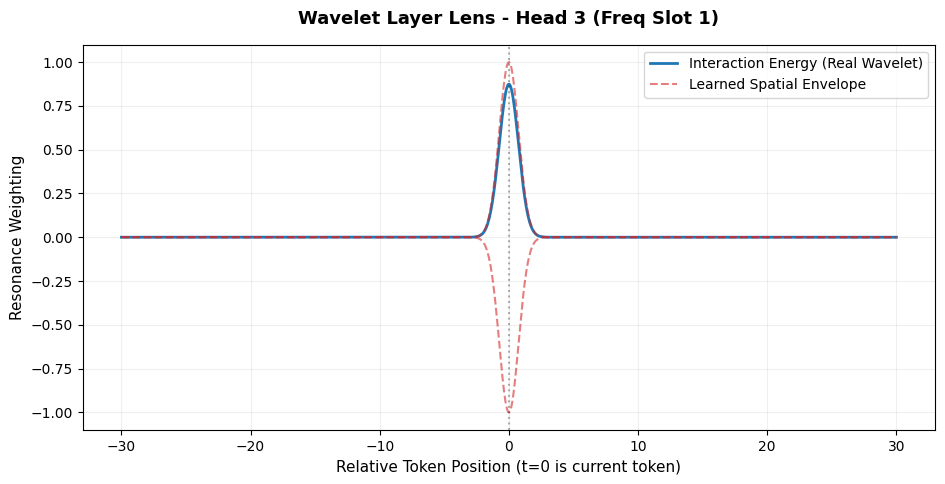

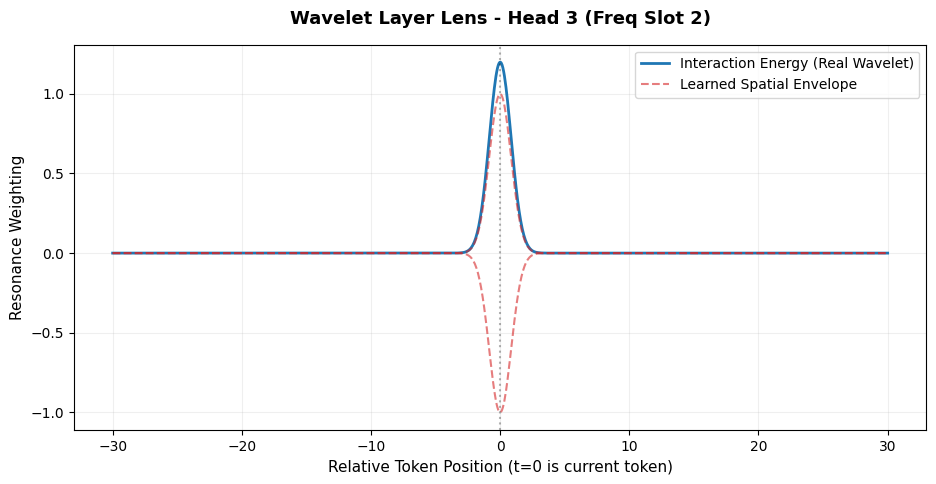

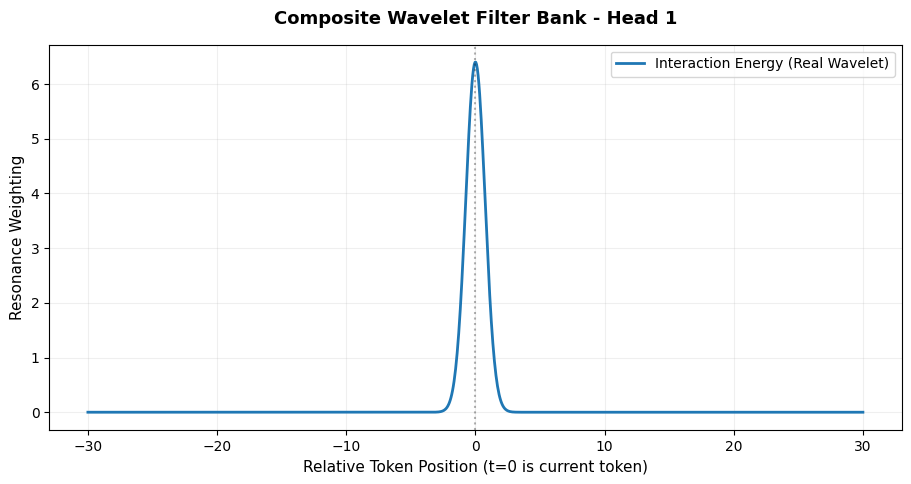

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

def plot_trained_wavelet(layer, head_idx, frequency_slot=None):
    """
    Plots the dynamically generated wavelet from a ParallelWaveletResonanceBlock layer
    by activating its hidden dimension projection.
    """
    layer.eval()

    w_heads = getattr(layer, 'wavelet_heads', getattr(layer, 'wave_let_heads', layer.num_heads // 2))
    assert head_idx < w_heads, f"Head index must be less than wavelet_heads ({w_heads})"

    with torch.no_grad():
        # 1. Grab the raw projection weights. Shape: (wavelet_heads, head_dim, 4, N)
        W_q = layer.W_q_wlet.detach().cpu()

        # 2. Simulate a highly active, uniform feature token passing into the head.
        # Shape: (head_dim,) filled with ones
        dummy_token = torch.ones(layer.head_dim)

        # 3. Project the dummy token through our target head's weight matrix.
        # This matches your forward pass einsum behavior!
        # Resulting shape: (4, N) -> [Amp, Freq, Phase, Decay] across all N frequencies
        head_params = torch.einsum('d, dmn -> mn', dummy_token, W_q[head_idx])

        # 4. Decode parameters exactly like your forward pass activations
        A = F.softplus(head_params[0])            # Amplitude
        omega = torch.abs(head_params[1]) * 2.0    # Frequency
        phi = torch.tanh(head_params[2]) * math.pi  # Phase
        gamma = F.softplus(head_params[3]) + 1e-4  # Decay Rate

    # 5. Generate relative token distance grid
    t = np.linspace(-30, 30, 1000)

    # 6. Compute Wavelet Math
    if frequency_slot is not None:
        assert frequency_slot < layer.N, f"Frequency slot must be less than N ({layer.N})"
        A_val = A[frequency_slot].item()
        omega_val = omega[frequency_slot].item()
        phi_val = phi[frequency_slot].item()
        gamma_val = gamma[frequency_slot].item()

        wave = A_val * np.cos(omega_val * t + phi_val)
        envelope = np.exp(-gamma_val * (t ** 2))
        wavelet = wave * envelope
        title = f"Wavelet Layer Lens - Head {head_idx} (Freq Slot {frequency_slot})"
    else:
        wavelet = np.zeros_like(t)
        envelope = np.zeros_like(t)
        for n in range(layer.N):
            w = A[n].item() * np.cos(omega[n].item() * t + phi[n].item())
            e = np.exp(-gamma[n].item() * (t ** 2))
            wavelet += w * e
            envelope += e * A[n].item()
        envelope /= layer.N
        title = f"Composite Wavelet Filter Bank - Head {head_idx}"

    # 7. Plotting Code
    plt.figure(figsize=(11, 5), facecolor='white')
    plt.plot(t, wavelet, label="Interaction Energy (Real Wavelet)", color='#1f77b4', linewidth=2)

    if frequency_slot is not None:
        plt.plot(t, envelope, '--', color='#d62728', alpha=0.6, label="Learned Spatial Envelope")
        plt.plot(t, -envelope, '--', color='#d62728', alpha=0.6)

    plt.title(title, fontsize=13, fontweight='bold', pad=15)
    plt.xlabel("Relative Token Position (t=0 is current token)", fontsize=11)
    plt.ylabel("Resonance Weighting", fontsize=11)
    plt.axvline(x=0, color='black', alpha=0.3, linestyle=':')
    plt.grid(True, alpha=0.2)
    plt.legend(loc="upper right", frameon=True)
    plt.show()
plot_trained_wavelet(model.layers[0], head_idx=3, frequency_slot=1)
plot_trained_wavelet(model.layers[0], head_idx=3, frequency_slot=2)

# Or visualize the combined composite filter of all frequencies on Layer 1, Head 3
plot_trained_wavelet(model.layers[1], head_idx=1, frequency_slot=None)

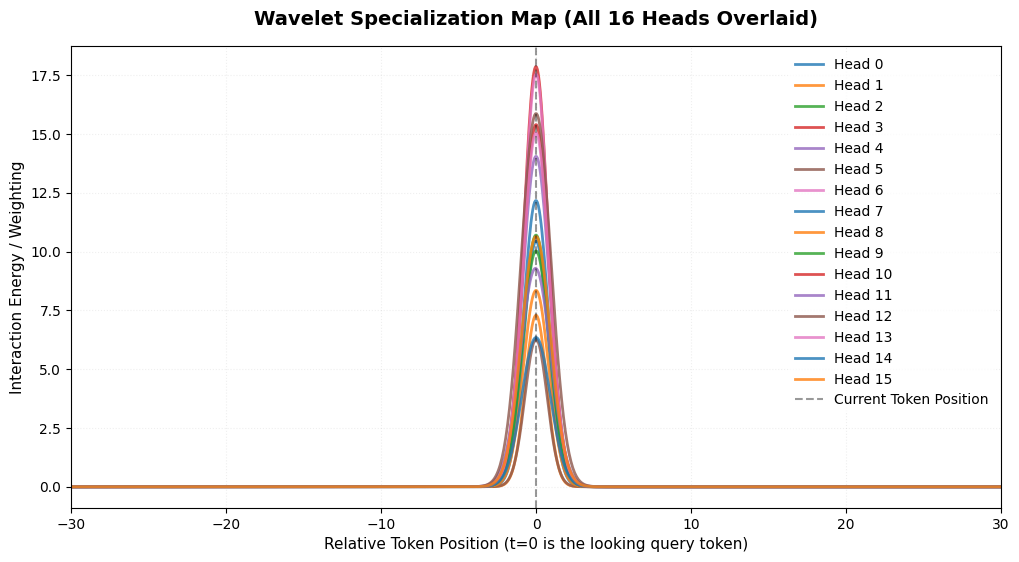

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

def plot_all_wavelets_combined(layer):
    """
    Overlays the composite wavelet filter from every single head
    in a ParallelWaveletResonanceBlock onto a single chart for comparison.
    """
    layer.eval()

    # Safely extract wavelet head count
    w_heads = getattr(layer, 'wavelet_heads', getattr(layer, 'wave_let_heads', layer.num_heads // 2))

    # Setup a clean timeline grid (-30 to +30 tokens)
    t = np.linspace(-30, 30, 1000)

    plt.figure(figsize=(12, 6), facecolor='white')

    # We will use a standard color cycle to give each head its own distinct look
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

    with torch.no_grad():
        W_q = layer.W_q_wlet.detach().cpu() # Shape: (wavelet_heads, head_dim, 4, N)
        dummy_token = torch.ones(layer.head_dim)

        # Loop through every head in this layer
        for head_idx in range(w_heads):
            # Project through the current head's weight matrix
            head_params = torch.einsum('d, dmn -> mn', dummy_token, W_q[head_idx])

            # Decode parameters
            A = F.softplus(head_params[0])
            omega = torch.abs(head_params[1]) * 2.0
            phi = torch.tanh(head_params[2]) * math.pi
            gamma = F.softplus(head_params[3]) + 1e-4

            # Reconstruct the composite wave for this head across all N frequencies
            composite_wavelet = np.zeros_like(t)
            for n in range(layer.N):
                w = A[n].item() * np.cos(omega[n].item() * t + phi[n].item())
                e = np.exp(-gamma[n].item() * (t ** 2))
                composite_wavelet += w * e

            # Choose a color from our cycle
            color = colors[head_idx % len(colors)]

            # Plot this head's wave line
            plt.plot(t, composite_wavelet, label=f"Head {head_idx}", color=color, linewidth=2, alpha=0.8)

    # Chart decorations
    plt.title(f"Wavelet Specialization Map (All {w_heads} Heads Overlaid)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Relative Token Position (t=0 is the looking query token)", fontsize=11)
    plt.ylabel("Interaction Energy / Weighting", fontsize=11)
    plt.axvline(x=0, color='black', alpha=0.4, linestyle='--', label="Current Token Position")
    plt.grid(True, alpha=0.2, linestyle=':')
    plt.legend(loc="upper right", frameon=True, facecolor='white', edgecolor='none')

    # Set tight limits so it feels readable
    plt.xlim(-30, 30)
    plt.show()

# Example Usage:
# Pass in whichever layer block you want to analyze
plot_all_wavelets_combined(model.layers[0])

In [ ]:
model

StackableWaveTransformer(
  (embedding): Embedding(50257, 128)
  (layers): ModuleList(
    (0-1): 2 x ParallelWaveletResonanceBlock(
      (value_haar): CausalHaarLayer(
        (proj): Linear(in_features=128, out_features=128, bias=True)
      )
      (head_mixer): Linear(in_features=128, out_features=128, bias=True)
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (lm_head): Linear(in_features=128, out_features=50257, bias=True)
)

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, LambdaLR

# --- 1. CONFIGURATION ---
BATCH_SIZE = 4
MAX_LENGTH = 64
TOTAL_STEPS = 5000
WARMUP_STEPS = 500
LR_MAX = 5e-4
LR_MIN = 5e-5

# --- 2. SETUP ---
# Ensure your model class includes the ParallelWaveletResonanceBlock
model = StackableWaveTransformer(
    vocab_size=len(tokenizer),
    embed_dim=256,
    num_layers=2,
    num_heads=8,
    num_frequencies=16
).to(device)

optimizer = optim.AdamW(model.parameters(), lr=LR_MAX, weight_decay=0.01)

# Linear Warmup + Cosine Decay Scheduler
def lr_lambda(current_step):
    if current_step < WARMUP_STEPS:
        return float(current_step) / float(max(1, WARMUP_STEPS))
    progress = float(current_step - WARMUP_STEPS) / float(max(1, TOTAL_STEPS - WARMUP_STEPS))
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = LambdaLR(optimizer, lr_lambda)

# --- 3. TRAINING LOOP ---
print(f"Starting Training: {TOTAL_STEPS} steps | LR Scheduler: Cosine Warmup")
model.train()
batch_gen = get_batch(dataset, tokenizer, batch_size=BATCH_SIZE, max_length=MAX_LENGTH)

for step in range(1, TOTAL_STEPS + 1):
    x, y = next(batch_gen)

    optimizer.zero_grad(set_to_none=True) # Critical for VRAM

    logits = model(x)
    loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1))

    loss.backward()

    # Gradient clipping is vital for the exponential terms in ResonanceAttention
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)

    optimizer.step()
    scheduler.step()

    if step % 50 == 0:
        print(f"Step {step:4d}/{TOTAL_STEPS} | Loss: {loss.item():.4f} | LR: {optimizer.param_groups[0]['lr']:.2e}")

    if step % 500 == 0:
        # Checkpoint Generation
        model.eval()
        with torch.no_grad():
            sample = generate_text(model, tokenizer, "The little robot found", max_new_tokens=30)
            print(f"\n--- Checkpoint {step} ---\nSample: {sample}\n" + "-"*30)
        model.train()
        torch.cuda.empty_cache()

Starting Training: 5000 steps | LR Scheduler: Cosine Warmup
Step   50/5000 | Loss: 10.3236 | LR: 5.00e-05
Step  100/5000 | Loss: 7.4653 | LR: 1.00e-04
Step  150/5000 | Loss: 5.4904 | LR: 1.50e-04
Step  200/5000 | Loss: 5.5081 | LR: 2.00e-04
Step  250/5000 | Loss: 4.9465 | LR: 2.50e-04
Step  300/5000 | Loss: 4.8607 | LR: 3.00e-04
Step  350/5000 | Loss: 4.3859 | LR: 3.50e-04
Step  400/5000 | Loss: 4.8425 | LR: 4.00e-04
Step  450/5000 | Loss: 4.3375 | LR: 4.50e-04
Step  500/5000 | Loss: 4.8351 | LR: 5.00e-04

--- Checkpoint 500 ---
Sample: The little robot found a walk time there were. One day, a little girl named was shining saw the sky. She was three years old and asked. She was playing
------------------------------
Step  550/5000 | Loss: 4.1877 | LR: 5.00e-04


Token indices sequence length is longer than the specified maximum sequence length for this model (1106 > 1024). Running this sequence through the model will result in indexing errors


Step  600/5000 | Loss: 4.1228 | LR: 4.99e-04
Step  650/5000 | Loss: 4.1699 | LR: 4.99e-04
Step  700/5000 | Loss: 3.4048 | LR: 4.98e-04
Step  750/5000 | Loss: 3.0978 | LR: 4.96e-04
Step  800/5000 | Loss: 5.1312 | LR: 4.95e-04
Step  850/5000 | Loss: 4.2162 | LR: 4.93e-04
Step  900/5000 | Loss: 4.2673 | LR: 4.90e-04
Step  950/5000 | Loss: 4.3109 | LR: 4.88e-04
Step 1000/5000 | Loss: 3.0818 | LR: 4.85e-04

--- Checkpoint 1000 ---
Sample: The little robot found a big piece other, they were playing in the sky of the sky, so he decided to see what it and the other, and said, "
------------------------------
Step 1050/5000 | Loss: 2.8424 | LR: 4.82e-04
Step 1100/5000 | Loss: 4.2261 | LR: 4.78e-04
Step 1150/5000 | Loss: 2.9306 | LR: 4.75e-04
Step 1200/5000 | Loss: 3.2190 | LR: 4.71e-04
Step 1250/5000 | Loss: 3.6508 | LR: 4.67e-04
Step 1300/5000 | Loss: 3.6375 | LR: 4.62e-04
Step 1350/5000 | Loss: 4.0016 | LR: 4.57e-04
Step 1400/5000 | Loss: 3.9821 | LR: 4.52e-04
Step 1450/5000 | Loss: 3.0506 | 

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class CausalHaarLayer(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.half_dim = embed_dim // 2
        self.proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        x_passthrough = x[..., :self.half_dim]
        x_wavelet = x[..., self.half_dim:]
        x_prev = F.pad(x_wavelet[:, :-1, :], (0, 0, 1, 0), value=0.0)
        low = (x_wavelet + x_prev) / 2.0
        return self.proj(torch.cat([x_passthrough, low], dim=-1))

class ParallelWaveletResonanceBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, num_frequencies):
        super().__init__()
        assert num_heads % 2 == 0, "Heads must be even"
        self.num_heads = num_heads
        self.wave_heads = num_heads // 2
        self.wavelet_heads = num_heads // 2
        self.head_dim = embed_dim // num_heads
        self.N = num_frequencies

        self.W_q_wave = nn.Parameter(torch.randn(self.wave_heads, self.head_dim, 3, self.N) * 0.05)
        self.W_k_wave = nn.Parameter(torch.randn(self.wave_heads, self.head_dim, 3, self.N) * 0.05)
        self.W_q_wlet = nn.Parameter(torch.randn(self.wavelet_heads, self.head_dim, 4, self.N) * 0.05)
        self.W_k_wlet = nn.Parameter(torch.randn(self.wavelet_heads, self.head_dim, 4, self.N) * 0.05)

        self.W_v = nn.Parameter(torch.randn(num_heads, embed_dim, self.head_dim) * 0.05)
        self.value_haar = CausalHaarLayer(embed_dim)
        self.log_sigma = nn.Parameter(torch.zeros(num_heads) + 1.0)
        self.head_mixer = nn.Linear(embed_dim, embed_dim)
        self.ln1 = nn.LayerNorm(embed_dim)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(0.1)

    def forward(self, h):
        B, S, E = h.shape
        residual = h
        h_norm = self.ln1(h)
        h_split = h_norm.view(B, S, self.num_heads, self.head_dim)

        # --- 1. GLOBAL GIST STREAM ---
        q_wave = torch.einsum('bshd, hdmn -> bshdmn', h_split[:, :, :self.wave_heads], self.W_q_wave)
        k_wave = torch.einsum('bshd, hdmn -> bshdmn', h_split[:, :, :self.wave_heads], self.W_k_wave)

        A_qw, o_qw, p_qw = F.softplus(q_wave[...,0,:]), torch.abs(q_wave[...,1,:])*2.0, torch.tanh(q_wave[...,2,:])*math.pi
        A_kw, o_kw, p_kw = F.softplus(k_wave[...,0,:]), torch.abs(k_wave[...,1,:])*2.0, torch.tanh(k_wave[...,2,:])*math.pi

        diff_omega_w = o_qw.unsqueeze(2) - o_kw.unsqueeze(1)
        res_w = torch.exp(-0.5 * torch.exp(self.log_sigma[:self.wave_heads]).view(1,1,1,-1,1,1) * (diff_omega_w**2)) * torch.cos(p_qw.unsqueeze(2)-p_kw.unsqueeze(1))
        energy_w = torch.sum(A_qw.unsqueeze(2) * A_kw.unsqueeze(1) * res_w, dim=-1).mean(dim=-1).permute(0,3,1,2)

        # --- 2. LOCAL WAVELET STREAM ---
        q_wlet = torch.einsum('bshd, hdmn -> bshdmn', h_split[:, :, self.wave_heads:], self.W_q_wlet)
        k_wlet = torch.einsum('bshd, hdmn -> bshdmn', h_split[:, :, self.wave_heads:], self.W_k_wlet)

        A_ql, o_ql, p_ql, g_ql = F.softplus(q_wlet[...,0,:]), torch.abs(q_wlet[...,1,:])*2.0, torch.tanh(q_wlet[...,2,:])*math.pi, F.softplus(q_wlet[...,3,:])+1e-4
        A_kl, o_kl, p_kl, g_kl = F.softplus(k_wlet[...,0,:]), torch.abs(k_wlet[...,1,:])*2.0, torch.tanh(k_wlet[...,2,:])*math.pi, F.softplus(k_wlet[...,3,:])+1e-4

        t_diff = (torch.arange(S, device=h.device).view(S,1) - torch.arange(S, device=h.device).view(1,S)).float().view(1,S,S,1,1,1)
        res_l = torch.exp(-0.5 * torch.exp(self.log_sigma[self.wave_heads:]).view(1,1,1,-1,1,1) * ((o_ql.unsqueeze(2)-o_kl.unsqueeze(1))**2)) * torch.cos(p_ql.unsqueeze(2)-p_kl.unsqueeze(1))
        env = torch.exp(-((g_ql.unsqueeze(2)+g_kl.unsqueeze(1))/2.0) * (t_diff**2))
        energy_l = torch.sum(A_ql.unsqueeze(2) * A_kl.unsqueeze(1) * res_l * env, dim=-1).mean(dim=-1).permute(0,3,1,2)

        # --- 3. TOP-DOWN GATING ---
        # The Gist (Global Energy) determines the precision of Local Details
        gist_signal = torch.sigmoid(energy_w.mean(dim=(-1, -2), keepdim=True))
        energy_l_gated = energy_l * gist_signal

        # --- 4. OUTPUT ---
        scores = torch.cat([energy_w, energy_l_gated], dim=1) / math.sqrt(self.head_dim)
        scores = scores + torch.triu(torch.full((S,S), float('-inf'), device=h.device), diagonal=1).view(1,1,S,S)

        attn = self.dropout(F.softmax(scores, dim=-1))
        V = torch.einsum('bse, hed -> bshd', self.value_haar(h_norm), self.W_v)
        context = torch.matmul(attn, V.permute(0,2,1,3)).permute(0,2,1,3).reshape(B, S, E)

        return residual + self.dropout(self.ln2(self.head_mixer(context)))

class StackableWaveTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, num_layers=2, num_heads=8, num_frequencies=16):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.layers = nn.ModuleList([ParallelWaveletResonanceBlock(embed_dim, num_heads, num_frequencies) for _ in range(num_layers)])
        self.lm_head = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        h = self.embedding(x)
        for layer in self.layers: h = layer(h)
        return self.lm_head(h)

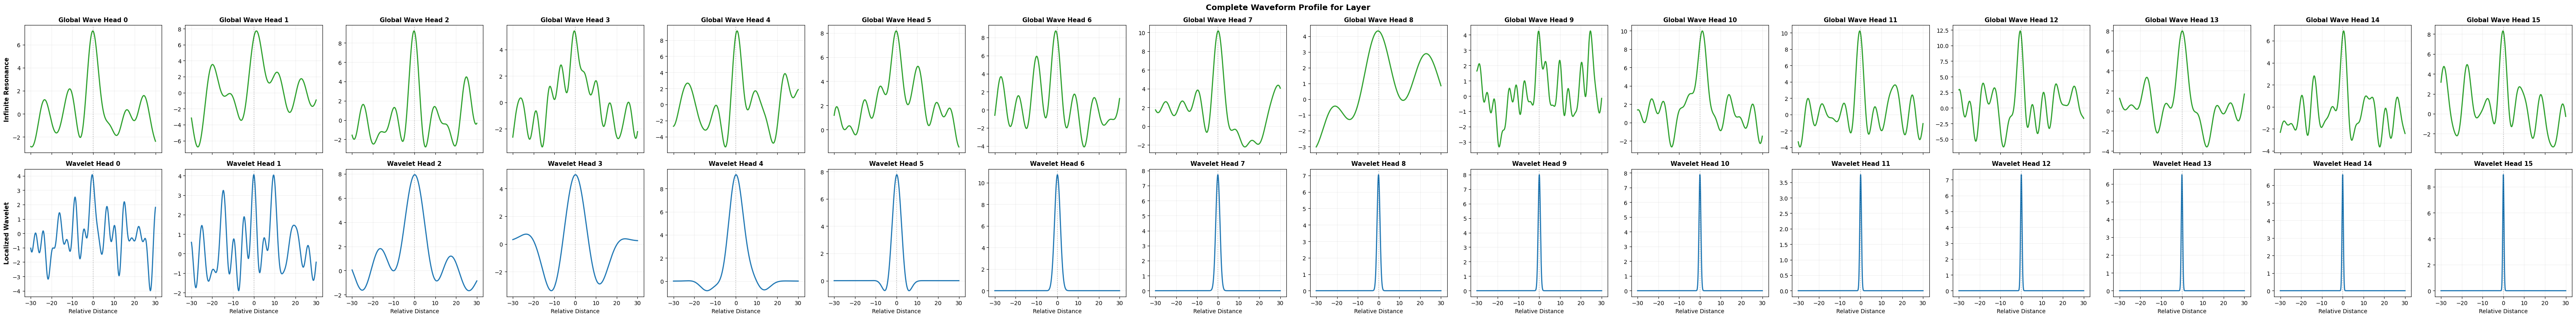

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

def visualize_complete_layer_waveforms(layer):
    """
    Plots the composite waveforms for ALL heads (both Global Wave heads
    and Localized Wavelet heads) side-by-side to visualize the entire layer profile.
    """
    layer.eval()

    # 1. Identify head counts
    total_heads = layer.num_heads
    wave_heads = layer.wave_heads
    wlet_heads = layer.wavelet_heads

    # Setup timeline grid (-30 to +30 tokens)
    t = np.linspace(-30, 30, 1000)
    dummy_token = torch.ones(layer.head_dim)

    # Create a subplot figure: Top row for Global Waves, Bottom row for Localized Wavelets
    fig, axes = plt.subplots(2, max(wave_heads, wlet_heads), figsize=(4 * max(wave_heads, wlet_heads), 8), sharex=True)
    fig.patch.set_facecolor('white')

    with torch.no_grad():
        # =====================================================================
        # ROW 1: PURE GLOBAL RESONANCE WAVES (Fourier Stream)
        # =====================================================================
        W_q_wave = layer.W_q_wave.detach().cpu() # Shape: (wave_heads, head_dim, 3, N)

        for h in range(wave_heads):
            # Project dummy token to decode [Amp, Freq, Phase]
            wave_params = torch.einsum('d, dmn -> mn', dummy_token, W_q_wave[h])
            A_w = F.softplus(wave_params[0])
            omega_w = torch.abs(wave_params[1]) * 2.0
            phi_w = torch.tanh(wave_params[2]) * math.pi

            # Reconstruct infinite composite wave
            composite_wave = np.zeros_like(t)
            for n in range(layer.N):
                composite_wave += A_w[n].item() * np.cos(omega_w[n].item() * t + phi_w[n].item())

            ax = axes[0, h] if wave_heads > 1 else axes[0]
            ax.plot(t, composite_wave, color='#2ca02c', linewidth=2)
            ax.set_title(f"Global Wave Head {h}", fontsize=11, fontweight='bold')
            ax.axvline(x=0, color='black', alpha=0.2, linestyle=':')
            ax.grid(True, alpha=0.2)
            if h == 0:
                ax.set_ylabel("Infinite Resonance", fontsize=11, fontweight='bold')

        # =====================================================================
        # ROW 2: LOCALIZED MORLET WAVELETS (Wavelet Stream)
        # =====================================================================
        W_q_wlet = layer.W_q_wlet.detach().cpu() # Shape: (wavelet_heads, head_dim, 4, N)

        for h in range(wlet_heads):
            # Project dummy token to decode [Amp, Freq, Phase, Decay]
            wlet_params = torch.einsum('d, dmn -> mn', dummy_token, W_q_wlet[h])
            A_l = F.softplus(wlet_params[0])
            omega_l = torch.abs(wlet_params[1]) * 2.0
            phi_l = torch.tanh(wlet_params[2]) * math.pi
            gamma_l = F.softplus(wlet_params[3]) + 1e-4

            # Reconstruct decaying composite wavelet
            composite_wlet = np.zeros_like(t)
            for n in range(layer.N):
                w = A_l[n].item() * np.cos(omega_l[n].item() * t + phi_l[n].item())
                e = np.exp(-gamma_l[n].item() * (t ** 2))
                composite_wlet += w * e

            ax = axes[1, h] if wlet_heads > 1 else axes[1]
            ax.plot(t, composite_wlet, color='#1f77b4', linewidth=2)
            ax.set_title(f"Wavelet Head {h}", fontsize=11, fontweight='bold')
            ax.axvline(x=0, color='black', alpha=0.2, linestyle=':')
            ax.grid(True, alpha=0.2)
            ax.set_xlabel("Relative Distance", fontsize=10)
            if h == 0:
                ax.set_ylabel("Localized Wavelet", fontsize=11, fontweight='bold')

    plt.suptitle(f"Complete Waveform Profile for Layer", fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

# Run it on your trained block:
visualize_complete_layer_waveforms(model.layers[0])

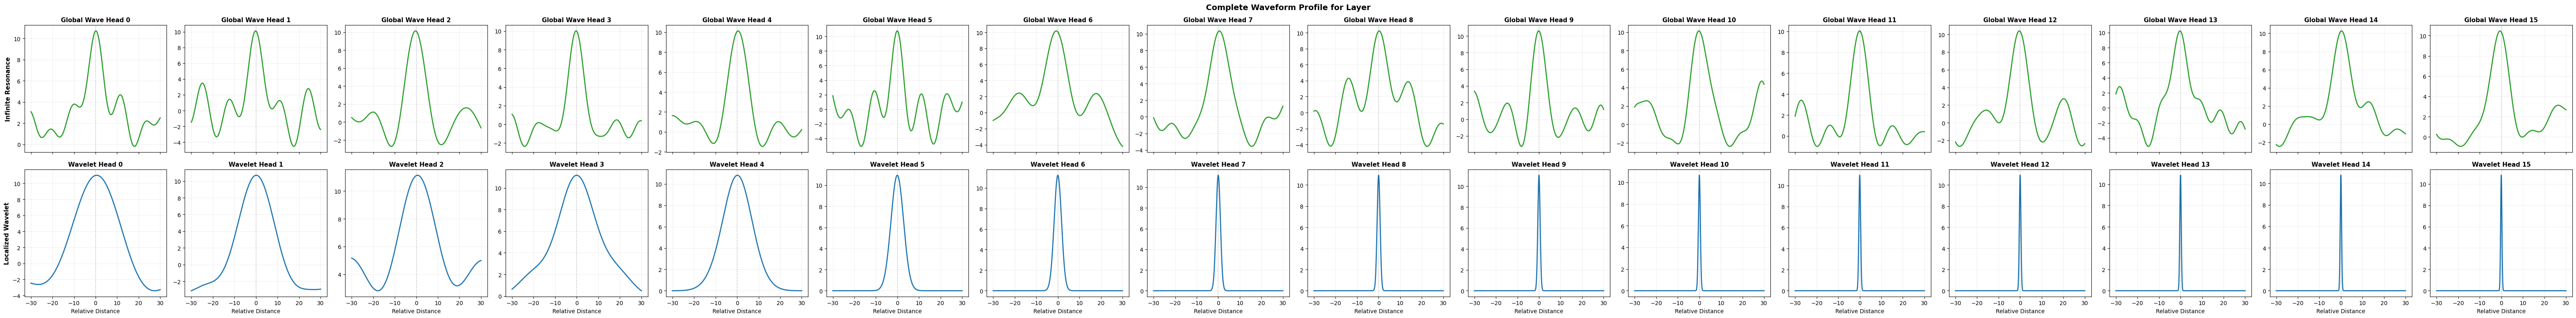

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

def visualize_complete_layer_waveforms(layer):
    """
    Plots the composite waveforms for ALL heads (both Global Wave heads
    and Localized Wavelet heads) side-by-side to visualize the entire layer profile.
    """
    layer.eval()

    # 1. Identify head counts
    total_heads = layer.num_heads
    wave_heads = layer.wave_heads
    wlet_heads = layer.wavelet_heads

    # Setup timeline grid (-30 to +30 tokens)
    t = np.linspace(-30, 30, 1000)
    dummy_token = torch.ones(layer.head_dim)

    # Create a subplot figure: Top row for Global Waves, Bottom row for Localized Wavelets
    fig, axes = plt.subplots(2, max(wave_heads, wlet_heads), figsize=(4 * max(wave_heads, wlet_heads), 8), sharex=True)
    fig.patch.set_facecolor('white')

    with torch.no_grad():
        # =====================================================================
        # ROW 1: PURE GLOBAL RESONANCE WAVES (Fourier Stream)
        # =====================================================================
        W_q_wave = layer.W_q_wave.detach().cpu() # Shape: (wave_heads, head_dim, 3, N)

        for h in range(wave_heads):
            # Project dummy token to decode [Amp, Freq, Phase]
            wave_params = torch.einsum('d, dmn -> mn', dummy_token, W_q_wave[h])
            A_w = F.softplus(wave_params[0])
            omega_w = torch.abs(wave_params[1]) * 2.0
            phi_w = torch.tanh(wave_params[2]) * math.pi

            # Reconstruct infinite composite wave
            composite_wave = np.zeros_like(t)
            for n in range(layer.N):
                composite_wave += A_w[n].item() * np.cos(omega_w[n].item() * t + phi_w[n].item())

            ax = axes[0, h] if wave_heads > 1 else axes[0]
            ax.plot(t, composite_wave, color='#2ca02c', linewidth=2)
            ax.set_title(f"Global Wave Head {h}", fontsize=11, fontweight='bold')
            ax.axvline(x=0, color='black', alpha=0.2, linestyle=':')
            ax.grid(True, alpha=0.2)
            if h == 0:
                ax.set_ylabel("Infinite Resonance", fontsize=11, fontweight='bold')

        # =====================================================================
        # ROW 2: LOCALIZED MORLET WAVELETS (Wavelet Stream)
        # =====================================================================
        W_q_wlet = layer.W_q_wlet.detach().cpu() # Shape: (wavelet_heads, head_dim, 4, N)

        for h in range(wlet_heads):
            # Project dummy token to decode [Amp, Freq, Phase, Decay]
            wlet_params = torch.einsum('d, dmn -> mn', dummy_token, W_q_wlet[h])
            A_l = F.softplus(wlet_params[0])
            omega_l = torch.abs(wlet_params[1]) * 2.0
            phi_l = torch.tanh(wlet_params[2]) * math.pi
            gamma_l = F.softplus(wlet_params[3]) + 1e-4

            # Reconstruct decaying composite wavelet
            composite_wlet = np.zeros_like(t)
            for n in range(layer.N):
                w = A_l[n].item() * np.cos(omega_l[n].item() * t + phi_l[n].item())
                e = np.exp(-gamma_l[n].item() * (t ** 2))
                composite_wlet += w * e

            ax = axes[1, h] if wlet_heads > 1 else axes[1]
            ax.plot(t, composite_wlet, color='#1f77b4', linewidth=2)
            ax.set_title(f"Wavelet Head {h}", fontsize=11, fontweight='bold')
            ax.axvline(x=0, color='black', alpha=0.2, linestyle=':')
            ax.grid(True, alpha=0.2)
            ax.set_xlabel("Relative Distance", fontsize=10)
            if h == 0:
                ax.set_ylabel("Localized Wavelet", fontsize=11, fontweight='bold')

    plt.suptitle(f"Complete Waveform Profile for Layer", fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

# Run it on your trained block:
visualize_complete_layer_waveforms(model.layers[0])

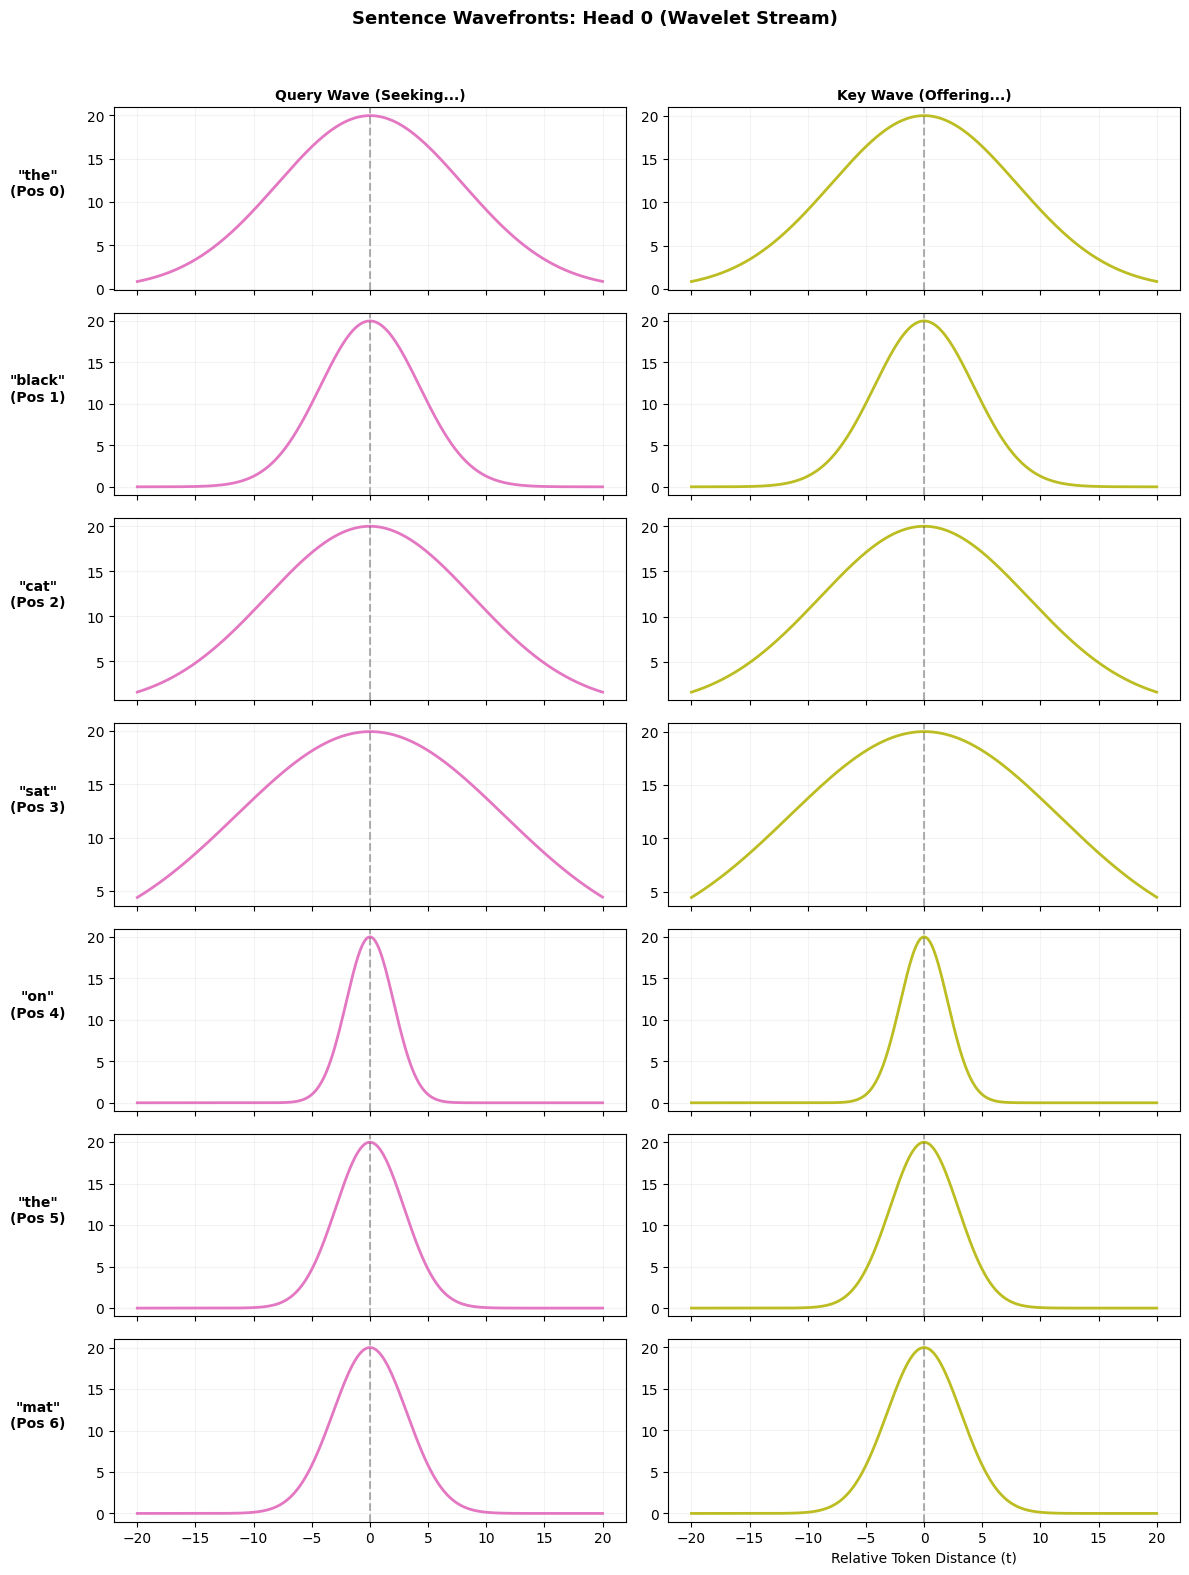

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

def plot_sentence_waveforms(model, layer_idx, head_idx, sentence_tokens, is_wavelet=True):
    """
    Extracts and plots the actual dynamic Q and K composite waveforms
    generated by a specific sentence of tokens for a given head.

    Correctly collapses the head_dim dimension to avoid NumPy broadcasting errors.
    """
    model.eval()
    layer = model.layers[layer_idx]
    device = next(model.parameters()).device

    # Track sequence indices directly to cleanly isolate duplicate words like "the"
    token_ids = torch.tensor([idx for idx in range(len(sentence_tokens))], dtype=torch.long, device=device)

    with torch.no_grad():
        h = model.embedding(token_ids).unsqueeze(0) # Shape: (1, S, E)
        for i in range(layer_idx):
            h = layer(h)
        h_norm = layer.ln1(h)

        B, S, E = h_norm.shape
        h_split = h_norm.view(B, S, layer.num_heads, layer.head_dim)

        if is_wavelet:
            h_wlet_split = h_split[:, :, layer.wave_heads:]
            # Raw Shape: (B=1, S=7, heads, head_dim, parameters=4, N=16)
            q_p = torch.einsum('bshd, hdmn -> bshdmn', h_wlet_split, layer.W_q_wlet)
            k_p = torch.einsum('bshd, hdmn -> bshdmn', h_wlet_split, layer.W_k_wlet)

            # --- THE CRITICAL FIX: Collapse head_dim (axis 3) via mean reduction ---
            q_p = q_p.mean(dim=3) # Shape becomes: (B=1, S=7, heads, parameters=4, N=16)
            k_p = k_p.mean(dim=3)

            # Extract parameters safely as clean (S, N) NumPy arrays
            A_q = torch.sigmoid(q_p[0, :, head_idx, 0, :]).detach().cpu().numpy() * 2.5
            omega_q = torch.abs(q_p[0, :, head_idx, 1, :]).detach().cpu().numpy() * 2.0
            phi_q = torch.tanh(q_p[0, :, head_idx, 2, :]).detach().cpu().numpy() * math.pi
            gamma_sig_q = torch.sigmoid(q_p[0, :, head_idx, 3, :])
            gamma_q = (0.002 + (gamma_sig_q * 0.15)).detach().cpu().numpy()

            A_k = torch.sigmoid(k_p[0, :, head_idx, 0, :]).detach().cpu().numpy() * 2.5
            omega_k = torch.abs(k_p[0, :, head_idx, 1, :]).detach().cpu().numpy() * 2.0
            phi_k = torch.tanh(k_p[0, :, head_idx, 2, :]).detach().cpu().numpy() * math.pi
            gamma_sig_k = torch.sigmoid(k_p[0, :, head_idx, 3, :])
            gamma_k = (0.002 + (gamma_sig_k * 0.15)).detach().cpu().numpy()

            dilation = layer.dilation_tensor[0, 0, 0, head_idx, 0, 0].cpu().item()
        else:
            h_wave_split = h_split[:, :, :layer.wave_heads]
            # Raw Shape: (B=1, S=7, heads, head_dim, parameters=3, N=16)
            q_p = torch.einsum('bshd, hdmn -> bshdmn', h_wave_split, layer.W_q_wave)
            k_p = torch.einsum('bshd, hdmn -> bshdmn', h_wave_split, layer.W_k_wave)

            # Collapse head_dim (axis 3)
            q_p = q_p.mean(dim=3)
            k_p = k_p.mean(dim=3)

            A_q = torch.sigmoid(q_p[0, :, head_idx, 0, :]).detach().cpu().numpy() * 2.5
            omega_q = torch.abs(q_p[0, :, head_idx, 1, :]).detach().cpu().numpy() * 2.0
            phi_q = torch.tanh(q_p[0, :, head_idx, 2, :]).detach().cpu().numpy() * math.pi
            gamma_q = None

            A_k = torch.sigmoid(k_p[0, :, head_idx, 0, :]).detach().cpu().numpy() * 2.5
            omega_k = torch.abs(k_p[0, :, head_idx, 1, :]).detach().cpu().numpy() * 2.0
            phi_k = torch.tanh(k_p[0, :, head_idx, 2, :]).detach().cpu().numpy() * math.pi
            gamma_k = None
            dilation = 1.0

    # High-resolution grid for computing smooth curves
    t = np.linspace(-20, 20, 1000)

    fig, axes = plt.subplots(S, 2, figsize=(12, 2.2 * S), sharex=True)
    if S == 1: axes = np.expand_dims(axes, axis=0)

    stream_title = "Wavelet" if is_wavelet else "Global Wave"
    plt.suptitle(f"Sentence Wavefronts: Head {head_idx} ({stream_title} Stream)", fontsize=13, fontweight='bold', y=1.02)

    for idx, token in enumerate(sentence_tokens):
        # 1. Synthesize Query Waveform
        comp_q = np.zeros_like(t)
        for n in range(layer.N):
            # Now these are clean, individual float scalars!
            wave = A_q[idx, n] * np.cos(omega_q[idx, n] * t + phi_q[idx, n])
            if gamma_q is not None:
                wave *= np.exp(-gamma_q[idx, n] * ((t / dilation) ** 2))
            comp_q += wave

        # 2. Synthesize Key Waveform
        comp_k = np.zeros_like(t)
        for n in range(layer.N):
            wave = A_k[idx, n] * np.cos(omega_k[idx, n] * t + phi_k[idx, n])
            if gamma_k is not None:
                wave *= np.exp(-gamma_k[idx, n] * ((t / dilation) ** 2))
            comp_k += wave

        # Plot Query Wave panel
        axes[idx, 0].plot(t, comp_q, color='#e377c2', linewidth=2)
        axes[idx, 0].axvline(x=0, color='black', alpha=0.3, linestyle='--')
        axes[idx, 0].grid(True, alpha=0.15)
        axes[idx, 0].set_ylabel(f'"{token}"\n(Pos {idx})', fontsize=10, fontweight='bold', rotation=0, labelpad=35)
        if idx == 0: axes[idx, 0].set_title("Query Wave (Seeking...)", fontsize=10, fontweight='bold')

        # Plot Key Wave panel
        axes[idx, 1].plot(t, comp_k, color='#bcbd22', linewidth=2)
        axes[idx, 1].axvline(x=0, color='black', alpha=0.3, linestyle='--')
        axes[idx, 1].grid(True, alpha=0.15)
        if idx == 0: axes[idx, 1].set_title("Key Wave (Offering...)", fontsize=10, fontweight='bold')

    plt.xlabel("Relative Token Distance (t)", fontsize=10)
    plt.tight_layout()
    plt.show()

# --- Example Usage Run ---
sentence = ["the", "black", "cat", "sat", "on", "the", "mat"]
plot_sentence_waveforms(model, layer_idx=0, head_idx=0, sentence_tokens=sentence, is_wavelet=True)

In [ ]:
device

'cuda'

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, LambdaLR

# --- 1. CONFIGURATION ---
BATCH_SIZE = 4
MAX_LENGTH = 64
TOTAL_STEPS = 5000
WARMUP_STEPS = 500
LR_MAX = 5e-4
LR_MIN = 5e-5

# --- 2. SETUP ---
# Ensure your model class includes the ParallelWaveletResonanceBlock
model = StackableWaveTransformer(
    vocab_size=len(tokenizer),
    embed_dim=256,
    num_layers=2,
    num_heads=8,
    num_frequencies=16
).to(device)

optimizer = optim.AdamW(model.parameters(), lr=LR_MAX, weight_decay=0.01)

# Linear Warmup + Cosine Decay Scheduler
def lr_lambda(current_step):
    if current_step < WARMUP_STEPS:
        return float(current_step) / float(max(1, WARMUP_STEPS))
    progress = float(current_step - WARMUP_STEPS) / float(max(1, TOTAL_STEPS - WARMUP_STEPS))
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = LambdaLR(optimizer, lr_lambda)

# --- 3. TRAINING LOOP ---
print(f"Starting Training: {TOTAL_STEPS} steps | LR Scheduler: Cosine Warmup")
model.train()
batch_gen = get_batch(dataset, tokenizer, batch_size=BATCH_SIZE, max_length=MAX_LENGTH)

for step in range(1, TOTAL_STEPS + 1):
    x, y = next(batch_gen)

    optimizer.zero_grad(set_to_none=True) # Critical for VRAM

    logits = model(x)
    loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1))

    loss.backward()

    # Gradient clipping is vital for the exponential terms in ResonanceAttention
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)

    optimizer.step()
    scheduler.step()

    if step % 50 == 0:
        print(f"Step {step:4d}/{TOTAL_STEPS} | Loss: {loss.item():.4f} | LR: {optimizer.param_groups[0]['lr']:.2e}")

    if step % 500 == 0:
        # Checkpoint Generation
        model.eval()
        with torch.no_grad():
            sample = generate_text(model, tokenizer, "The little robot found", max_new_tokens=30)
            print(f"\n--- Checkpoint {step} ---\nSample: {sample}\n" + "-"*30)
        model.train()
        torch.cuda.empty_cache()

Starting Training: 5000 steps | LR Scheduler: Cosine Warmup
Step   50/5000 | Loss: 10.4528 | LR: 5.00e-05
Step  100/5000 | Loss: 7.4256 | LR: 1.00e-04
Step  150/5000 | Loss: 5.4990 | LR: 1.50e-04
Step  200/5000 | Loss: 5.6318 | LR: 2.00e-04
Step  250/5000 | Loss: 4.9866 | LR: 2.50e-04
Step  300/5000 | Loss: 4.7722 | LR: 3.00e-04
Step  350/5000 | Loss: 4.3547 | LR: 3.50e-04
Step  400/5000 | Loss: 4.9651 | LR: 4.00e-04
Step  450/5000 | Loss: 4.3046 | LR: 4.50e-04
Step  500/5000 | Loss: 4.9368 | LR: 5.00e-04

--- Checkpoint 500 ---
Sample: The little robot found. One day and saw his mom, "What was three. The was having a loud a lot. He said, " he was a loud he
------------------------------
Step  550/5000 | Loss: 4.2650 | LR: 5.00e-04
Step  600/5000 | Loss: 4.1389 | LR: 4.99e-04
Step  650/5000 | Loss: 4.1597 | LR: 4.99e-04
Step  700/5000 | Loss: 3.5247 | LR: 4.98e-04
Step  750/5000 | Loss: 3.1157 | LR: 4.96e-04
Step  800/5000 | Loss: 5.1301 | LR: 4.95e-04
Step  850/5000 | Loss: 4.2319 | L

In [ ]:
# IDEA 1: adding in a "concept head"

class ParallelWaveletResonanceBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, num_frequencies, num_concepts=32):
        super().__init__()
        self.num_heads = num_heads
        self.wave_heads = num_heads // 2
        self.wavelet_heads = num_heads // 2
        self.head_dim = embed_dim // num_heads

        # --- CONCEPT BANK (The "Expert Router") ---
        self.num_concepts = num_concepts
        self.concept_bank = nn.Parameter(torch.randn(num_concepts, embed_dim) * 0.02)
        # Learns which concepts activate which heads
        self.concept_to_head_proj = nn.Linear(num_concepts, num_heads)

        # ... [Keep W_q_wave, W_k_wave, W_q_wlet, W_k_wlet, W_v, log_sigma] ...

        # NOTE: Be sure to initialize these params as per your previous code

    def forward(self, h):
        B, S, E = h.shape
        residual = h
        h_norm = self.ln1(h)

        # --- 1. CONCEPT GROUNDING & ROUTING ---
        # Determine the "concept" of every token
        # (B, S, E) @ (E, C) -> (B, S, C)
        concept_logits = torch.matmul(h_norm, self.concept_bank.T) / math.sqrt(E)
        concept_attn = F.softmax(concept_logits, dim=-1)

        # Map concepts to head importance (The "Gate")
        # (B, S, C) -> (B, S, num_heads)
        head_gate = torch.sigmoid(self.concept_to_head_proj(concept_attn))

        # Split gate for Wave and Wavelet streams
        gate_w = head_gate[:, :, :self.wave_heads].unsqueeze(-1).unsqueeze(-1) # (B, S, Hw, 1, 1)
        gate_l = head_gate[:, :, self.wave_heads:].unsqueeze(-1).unsqueeze(-1) # (B, S, Hl, 1, 1)

        # --- 2. ENERGY COMPUTATION WITH GATING ---
        # Apply head_gate to energy matrices immediately after projection/res calc
        # Example for Wave stream:
        # res_w is shape (B, S, S, Hw, 1, N)
        # Apply gate_w: energy_w = energy_raw * gate_w (broadcasted)

        # IMPORTANT: Apply the gate to the attention scores
        # scores = torch.cat([energy_w * gate_w, energy_l * gate_l], dim=1)

        # ... [Rest of your energy logic] ...

        return residual + self.dropout(self.ln2(self.head_mixer(context)))